In [18]:
fn = '53engaging_correctedsnE'

In [21]:
mod_type = 'default'
subset = False
short_run = False
seed_split = 888
visualize = True
drop_low_counts = True
run_type = fn[-1]

cat_col = 'seurat_annotations'
pert_col = 'stim'

In [20]:
n_fraction = 0.2

train_frac, test_frac = 0.8, 0.2

a_scale = 10
b_scale = 2


In [4]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning, module="anndata.utils")
from scipy.sparse import SparseEfficiencyWarning
with warnings.catch_warnings():
    warnings.simplefilter("ignore", SparseEfficiencyWarning)

import os
from typing import Optional, Dict, List, Literal
import copy
import itertools
from tqdm import tqdm
from tqdm import trange
import gc
import math

import pandas as pd
import numpy as np
import scanpy as sc

import networkx as nx

from scipy import stats
from sklearn.metrics import normalized_mutual_info_score
import torch
from scipy.cluster.hierarchy import fclusterdata

import scanpy as sc
import pandas as pd
from typing import List, Literal
import torch
from geomloss import SamplesLoss
import torch.nn as nn

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns

from sklearn.model_selection import train_test_split



/orcd/pool/005/hmbaghda/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/scanpy/_utils/__init__.py:33: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
/orcd/pool/005/hmbaghda/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/scanpy/__init__.py:24: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/orcd/pool/005/hmbaghda/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/scanpy/readwrite.py:16: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):


In [5]:
import sys
sclembas = '/home/hmbaghda/Projects/scLEMBAS'
sys.path.insert(1, os.path.join(sclembas))
from scLEMBAS import io

# from scLEMBAS.model.train_dev_mu_regularizer import TrainSC as TrainSCDevMu
# from scLEMBAS.model.train_dev_weights_standard import TrainSC as TrainSCDevWstandard
from scLEMBAS.model.train import TrainSC
from scLEMBAS.preprocess import discriminator_weight_curve, get_alignment_score
from scLEMBAS import latent_separation as ls


# from scLEMBAS.model.scl_dev_tot_scaler import SignalingModel as SignalingModelDevTot
# from scLEMBAS.model.scl_dev_global_scaler import SignalingModel as SignalingModelDevGlobal
# from scLEMBAS.model.scl_dev_mu_scaler import SignalingModel as SignalingModelDevMu
# from scLEMBAS.model.scl_dev_weights_standard import SignalingModel as SignalingModelDevWstandard
from scLEMBAS.model.scl import SignalingModel

SM = {'default': SignalingModel}#, 
#      'tot_bias_scaler': SignalingModelDevTot, 
#      'global_bias_scaler': SignalingModelDevGlobal, 
#      'mu_bias_scaler': SignalingModelDevMu, 
#      'global_bias_regularizer': SignalingModel, 
#      'mu_bias_regularizer': SignalingModel,
#      'standardized_weights': SignalingModelDevWstandard # initializes weights much larger
#      }

TR = {'default': TrainSC}#, 
#      'tot_bias_scaler': TrainSC, 
#      'global_bias_scaler': TrainSC, 
#      'mu_bias_scaler': TrainSC, 
#      'global_bias_regularizer': TrainSC, # by default, regularizes global bias
#       'mu_bias_regularizer': TrainSCDevMu, 
#       'standardized_weights': TrainSCDevWstandard 
#      }

sys.path.insert(1, '/home/hmbaghda/Projects/scLEMBAS/notebooks/Kang_2017/')
from Kang_utils import (rev_stim, stim_map, rev_stim_map, adata_dimviz_bias, clear_memory,
                        get_prediction, adata_dimviz_prediction, prepare_for_metrics, get_loss)


/orcd/pool/005/hmbaghda/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
n_cores = 30
os.environ["OMP_NUM_THREADS"] = str(n_cores)
os.environ["MKL_NUM_THREADS"] = str(n_cores)
os.environ["OPENBLAS_NUM_THREADS"] = str(n_cores)
os.environ["VECLIB_MAXIMUM_THREADS"] = str(n_cores)
os.environ["NUMEXPR_NUM_THREADS"] = str(n_cores)

data_path = '/home/hmbaghda/orcd/pool/scLEMBAS/analysis'
device = "cuda" if torch.cuda.is_available() else "cpu"

In [7]:
adata = sc.read_h5ad(os.path.join(data_path, 'processed', 'kang_expr_scored.h5ad'))
sn_ppis = pd.read_csv(os.path.join(data_path, 'processed', 'Kang_sn_ppis.csv'), index_col = 0)

tf_adata = io.read_tfad(os.path.join(data_path, 'processed', 'Kang_tf_activity.h5ad'))
tf_adata.obs['condition'] = tf_adata.obs['stim'].astype(str) + '^' + tf_adata.obs['seurat_annotations'].astype(str)

# ensures correct order of test data
# note, this already saved in order, matching the mod.y_out columns
tf_adata = tf_adata[:, sorted(tf_adata.var_names)] 

source_label = 'source_genesymbol'
target_label = 'target_genesymbol'
weight_label = 'mode_of_action'
stimulation_label = 'consensus_stimulation'
inhibition_label = 'consensus_inhibition'


In [8]:
if drop_low_counts:
    drop_ct = tf_adata.obs.seurat_annotations.value_counts().index.tolist()[-3:]
    tf_adata = tf_adata[~tf_adata.obs.seurat_annotations.isin(drop_ct)]
    adata = adata[tf_adata.obs_names,:]

# Checkpoint: load the object

In [12]:
trainer = io.read_pickled_object(os.path.join(data_path, 'trash', fn + '_feb_trainer.pickle'))
mod = trainer.mod

test_cells = trainer.X_test.index.tolist()
train_cells = trainer.X_train.index.tolist()

train_cond = sorted(tf_adata[train_cells, :].obs.condition.unique())
train_conds = train_cond
test_cond = sorted(tf_adata[test_cells, :].obs.condition.unique())
test_conds = test_cond
seed = mod.seed

test_cell_types = sorted(pd.Series([ct.split('^')[1] for ct in test_conds]).drop_duplicates(keep = 'first').tolist())
train_cell_types = pd.Series([ct.split('^')[1] for ct in train_conds]).drop_duplicates(keep = 'first').tolist()
train_cell_types = sorted(set(train_cell_types).difference(test_cell_types))



In [13]:
if torch.isinf(mod.signaling_network.weights).any():
    raise ValueError('Exploding gradients')

In [23]:
print('Index: {}'.format(fn))
# if not any(letter in fn for letter in ['A', 'B', 'C', 'D', 'E']):
loo_ = True if trainer.X_test.shape[0] < 1000 else False
if not loo_:
    run_type_ = 'E'
else:
    seed_ = mod.seed
    stim_ = test_conds[0].split('^')[0]

    if stim_ == 'CTRL':
        if seed_ == 3:
            run_type_ = 'B'
        elif seed_ == 1:
            run_type_ = 'A'
    elif stim_ == 'STIM':
        if seed_ == 7:
            run_type_ = 'C'
        elif seed == 10:
            run_type_ = 'D'
if run_type_ != run_type:
    raise ValueError('Problem in run type logic')
print('Run type: ' + run_type)

print()
print('-----Adj REGULARIZATIONS-----------')
print('adj reg: {:.3E}'.format(trainer.hyper_params['bn_weights_lambda_L2']))
print('uniform reg: {:.3E}'.format(trainer.hyper_params['uniform_lambda_L2']))

if not ('adj_scaling_KL' in trainer.hyper_params):
    for hp in ['adj_scaling_KL', 'adj_prior_mu', 'adj_prior_sigma']:
        trainer.hyper_params[hp] = None
askl = trainer.hyper_params['adj_scaling_KL']
print('Adj scaling KL: {:.3E}'.format(trainer.hyper_params['adj_scaling_KL']) if askl is 
      not None else 'Adj scaling KL: None')
print('Adj KL Dist: N({:.2f}, {:.2f})'.format(trainer.hyper_params['adj_prior_mu'], 
                                         trainer.hyper_params['adj_prior_sigma']) if askl is not None else 'Adj KL Dist: None')

print()
print('-----Global Bias REGULARIZATIONS-----------')
if not ('vae_prior_mu' in trainer.hyper_params):
    trainer.vae_learning['params']['prior_mu'] = 0
    trainer.vae_learning['params']['prior_sigma'] = 1
print('Global Bias scaling KL: {:.3E}'.format(trainer.vae_learning['params']['scaling_KL']))
print('Global Bias KL Dist: N({:.2f}, {:.2f})'.format(trainer.vae_learning['params']['prior_mu'], 
                                         trainer.vae_learning['params']['prior_sigma']))


for hp in ['global_bias_lambda_L2', 'global_bias_lambda_L1', 'cat_bias_lambda_L2', 
          'cat_bias_lambda_L1', 'cat_bias_orthogonality_scaler']:
    if not (hp in trainer.hyper_params):
        trainer.hyper_params[hp] = 0
        
print('global bias L2 reg: {:.3E}'.format(trainer.hyper_params['global_bias_lambda_L2']))
print('global bias L1 reg: {:.3E}'.format(trainer.hyper_params['global_bias_lambda_L1']))
# print('VAE reg: {:.3E}'.format(trainer.vae_learning['params']['lambda_l2']))

print()
print('-----Categorical Bias REGULARIZATIONS-----------')
print('cat max norm: {}'.format(mod.signaling_network.bionet_params['cat_max_norm']))
print('cat bias L2 reg: {:.3E}'.format(trainer.hyper_params['cat_bias_lambda_L2']))
print('cat bias L1 reg: {:.3E}'.format(trainer.hyper_params['cat_bias_lambda_L1']))
print()

if 'cat_pert' in trainer.hyper_params:
    for k,v in trainer.hyper_params['cat_pert'].items():
        if k != 'temperature':
            print('Cat pert regularization ' + k + ': {}'.format(v))
else:
    print('cat bias orthogonality scaler: {:.3f}'.format(trainer.hyper_params['cat_bias_orthogonality_scaler']))

print()
print('-----LOSS FUNCTION-----------')
if 'per_condition_loss' in trainer.__dict__.keys():
    new_loss = True
    loss_type = trainer._prediction_loss_name
else:
    new_loss = False
    loss_type = 'EMD'
    
if new_loss and trainer.per_condition_loss:
    print('Loss was calculated per-condition')
else:
    print('Loss was calculated on all conditions simultaneously')
print('The loss function used is: ' + loss_type)

print()
print('-----NOISE-----------')
if 'include_gradient_noise_vae' not in trainer.hyper_params:
    _noise_params = [0.01, 0, True, True, True, 1e-9]
else: 
    _noise_params = [trainer.hyper_params['network_noise_scale'], 
                    trainer.hyper_params['min_network_noise'], 
                    trainer.hyper_params['include_gradient_noise_vae'], 
                    trainer.hyper_params['include_gradient_noise_embedding'], 
                    trainer.hyper_params['constant_gradient_noise'], 
                    trainer.hyper_params['gradient_noise_scale']]
_noise_params = [nl.item() if type(nl) == torch.Tensor else nl for nl in _noise_params]
print('Network Noise: scaler: {:.3e} | min: {:.3e}'.format(*_noise_params[:2]))
print('Gradient Noise: vae included: {} | cat_embedding_included: {}'.format(*_noise_params[2:4]))
print('Gradient Noise: scaler included: {:.3e} | constant: {}'.format(*_noise_params[4:][::-1]))

print()
print('-----Adversarial Tuning-----------')
print('Train batch size: {}'.format(trainer.hyper_params['train_batch_size']))
print()

sl = False
if 'smooth_labels' in trainer.pert_discriminator['discriminator'].__dict__:
    sl = trainer.pert_discriminator['discriminator'].smooth_labels
ga = False
if 'gradient_ascent' in trainer.__dict__ and trainer.gradient_ascent:
    ga = True

print('Label smoothing: {}'.format(sl))
print('Gradient ascent: {}'.format(ga))

print()
# print('Min/max Discriminator LR: ({:.2E}, {:.2E})'.format(trainer.pert_discriminator['params']['minimum_learning_rate'],
#                                                         trainer.pert_discriminator['params']['maximum_learning_rate']))

print('Cat discriminator weight min/max: ({:.1f}, {:.1f})'.format(min(trainer.cat_discriminator['params']['discriminator_penalty_weight']), 
                                                            max(trainer.cat_discriminator['params']['discriminator_penalty_weight'])))

print('Pert discriminator weight min/max: ({:.1f}, {:.1f})'.format(min(trainer.pert_discriminator['params']['discriminator_penalty_weight']), 
                                                            max(trainer.pert_discriminator['params']['discriminator_penalty_weight'])))

print()
print('Cat discriminator dropout rate: {}'.format(trainer.cat_discriminator['params']['dropout_rate']))
print('Pert discriminator dropout rate: {}'.format(trainer.pert_discriminator['params']['dropout_rate']))
print()
bm = False if trainer.pert_discriminator['params']['batch_momentum'] is None else True
print('Discriminator batch normalization: {}'.format(bm))
sn = False
if 'spectral_norm' in trainer.pert_discriminator['params']:
    sn = trainer.pert_discriminator['params']['spectral_norm']
print('Discriminator spectral normalization: {}'.format(sn))
print('Discriminator L2 regularization: {:.2E}'.format(trainer.pert_discriminator['params']['discriminator_lambda_L2']))
print()
print('Generator dropout rate: {}'.format(trainer.mod.signaling_network.bionet_params['vae_dropout_rate']))

print()
n_adversarial_start, n_discriminator_train = 0, 1
if hasattr(trainer, 'n_adversarial_start'):
    n_adversarial_start = trainer.n_adversarial_start
if hasattr(trainer, 'n_discriminator_train'):
    n_discriminator_train = trainer.n_discriminator_train
print('Adversarial start epoch: {}'.format(n_adversarial_start))
print('Generator train frequency: {}'.format(n_discriminator_train))   

print()
print('-----Learning Rates-----------')
print('Main max LR: {:.2E}'.format(trainer.hyper_params['maximum_learning_rate']))
print('Generator max LR: {:.2E}'.format(trainer.vae_learning['params']['maximum_learning_rate']))
print('Cat discriminator max LR: {:.2E}'.format(trainer.cat_discriminator['params']['maximum_learning_rate']))
print('Pert discriminator max LR: {:.2E}'.format(trainer.pert_discriminator['params']['maximum_learning_rate']))
print()
print('LR decay: {:.1f}'.format(trainer.hyper_params['lr_decay']))

print()
print('-----UNNECESSARY REGULARIZATIONS-----------')
print('Spectral loss regularization: {:.2E}'.format(trainer.hyper_params['spectral_loss_factor']))
print('Uniform regularization: {:.2E}'.format(trainer.hyper_params['uniform_lambda_L2']))


print()
print('-----OTHER-----------')
print('epochs: {}'.format(trainer.hyper_params['max_epochs']))
print('seed: {}'.format(mod.seed))
print('test cells: {}'.format(trainer.X_test.shape))
print('Reset optimizer epoch: {}'.format(trainer.hyper_params['reset_optimizer_epoch']))



Index: 53engaging_correctedsnE
Run type: E

-----Adj REGULARIZATIONS-----------
adj reg: 1.000E-07
uniform reg: 0.000E+00
Adj scaling KL: 0.000E+00
Adj KL Dist: N(0.00, 0.20)

-----Global Bias REGULARIZATIONS-----------
Global Bias scaling KL: 1.000E-03
Global Bias KL Dist: N(0.00, 1.00)
global bias L2 reg: 0.000E+00
global bias L1 reg: 0.000E+00

-----Categorical Bias REGULARIZATIONS-----------
cat max norm: 100.0
cat bias L2 reg: 1.000E-04
cat bias L1 reg: 0.000E+00

Cat pert regularization regularization_scaler: 100.0
Cat pert regularization method: orthogonality
Cat pert regularization per_label: False
Cat pert regularization include_adjacency: False

-----LOSS FUNCTION-----------
Loss was calculated per-condition
The loss function used is: MSE

-----NOISE-----------
Network Noise: scaler: 1.000e-02 | min: 2.500e-03
Gradient Noise: vae included: True | cat_embedding_included: True
Gradient Noise: scaler included: 1.000e-09 | constant: True

-----Adversarial Tuning-----------
Train 

''

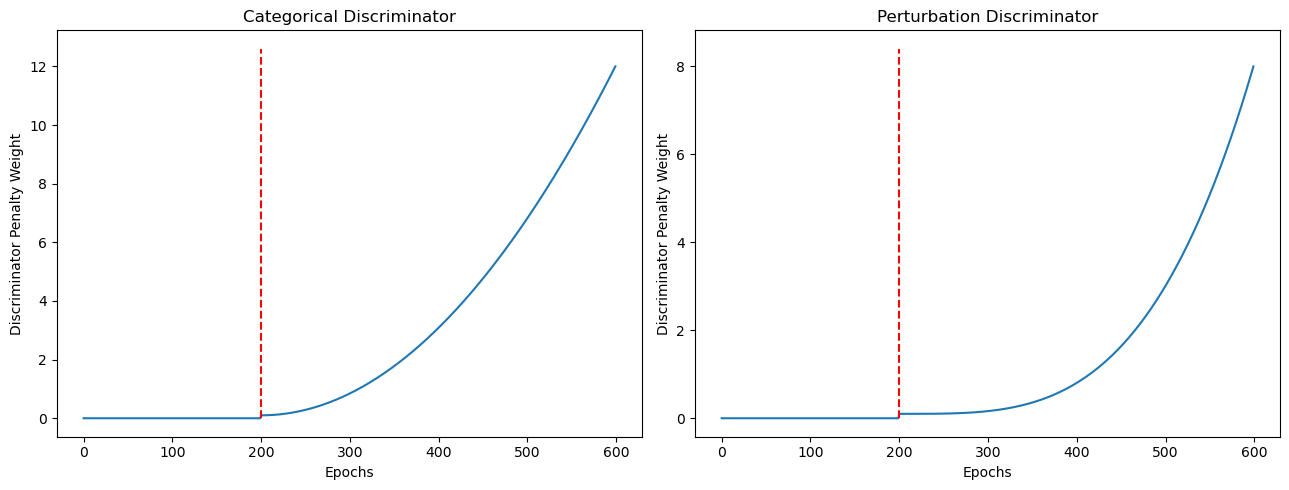

In [24]:
if 'cat_discriminator' not in trainer.__dict__.keys():
    trainer.cat_discriminator = trainer.discriminator

fig, ax = plt.subplots(ncols = 2, figsize = (13,5))
sns.lineplot(trainer.cat_discriminator['params']['discriminator_penalty_weight'], ax = ax[0])
ax[0].vlines(n_adversarial_start, ymin = 0, ymax = ax[0].get_ylim()[1], color = 'red', linestyle = '--')
ax[0].set_title('Categorical Discriminator')

if 'pert_discriminator' in trainer.__dict__.keys():
    sns.lineplot(trainer.pert_discriminator['params']['discriminator_penalty_weight'], ax = ax[1])
ax[1].vlines(n_adversarial_start, ymin = 0, ymax = ax[1].get_ylim()[1], color = 'red', linestyle = '--')
ax[1].set_title('Perturbation Discriminator')

for i in range(2):
    ax[i].set_xlabel('Epochs')
    ax[i].set_ylabel('Discriminator Penalty Weight')
    
fig.tight_layout()
;


In [25]:
train_stats_df = trainer.stats['train'].copy()
train_stats_df = train_stats_df.groupby('epoch').mean().reset_index() # delete this

In [26]:
train_stats_df = trainer.stats['train'].copy()
train_stats_df = train_stats_df.groupby('epoch').mean().reset_index() # delete this

explode = False
if train_stats_df['vae_grad_l2_norm'].max() > 10*train_stats_df['vae_grad_l2_norm'].median():
    raise ValueError('This should no longer be an issue with gradient clipping')
#     print('!!!Likely had exploding gradients for generator!!!')
#     explode = True
#     for col in ['train_loss_total', 'global_bias_kl_divergence', 'vae_grad_l2_norm', 
#                'cat_adverserial_loss', 'pert_adverserial_loss']:
#         col_median = train_stats_df[col].median()
#         train_stats_df.loc[train_stats_df[col] > 10*col_median, col] = np.nan

# formatting new/old versions
if 'sn_param_reg_loss' in train_stats_df.columns:
    train_stats_df.rename(columns = {'sn_param_reg_loss': 'sn_param_reg_tot_loss'}, 
                      inplace = True)
if 'output_param_reg_loss' in train_stats_df.columns:
    train_stats_df.rename(columns = {'output_param_reg_loss': 'output_param_reg_tot_loss'}, 
                      inplace = True)
    
if 'kl_divergence' in train_stats_df.columns:
    train_stats_df.rename(columns = {'kl_divergence': 'global_bias_kl_divergence'}, 
                      inplace = True)
    
if 'sn_param_reg_weights_kl_divergence' not in train_stats_df.columns:
    train_stats_df['sn_param_reg_weights_kl_divergence'] = 0
    
    
sn_param_loss_cols = ['sn_param_reg_weights_L2_loss',
             'sn_param_reg_weights_kl_divergence',
             'sn_param_reg_global_bias_L2_loss', 
             'sn_param_reg_global_bias_L1_loss',
             'sn_param_reg_cat_bias_L2_loss', 
             'sn_param_reg_cat_bias_L1_loss',
             'sn_param_reg_cat_bias_pert']
for col in sn_param_loss_cols + ['output_param_reg_weights_loss', 'output_param_reg_bias_loss']:
    if col not in train_stats_df.columns:
        train_stats_df[col] = 0 # not necessarily accurate but helps print things out
        
        
for col in ['discriminator_learning_rate', 'discriminator_loss_total',
           'discriminator_loss_prediction', 'discriminator_param_reg_loss']:
    if col in train_stats_df.columns:
        train_stats_df.rename(columns = {col: 'cat_'+ col}, 
                  inplace = True)
        
for col in ['vae_grad_l2_norm', 'pert_discriminator_learning_rate', 'pert_discriminator_loss_total',
           'pert_discriminator_loss_prediction', 'pert_discriminator_param_reg_loss', 
           'cat_seurat_annotations_discriminator_grad_l2_norm', 
           'pert_discriminator_grad_l2_norm']:
    if col not in train_stats_df.columns:
        train_stats_df[col] = 0

# if 'test' in trainer.stats:
#     test_stats_df = trainer.stats['test'].copy()
#     test_stats_df = test_stats_df.groupby('epoch').mean().reset_index() # DELETE THIS

# 4. Look at the loss curves:

In [ ]:
viz_df = train_stats_df.copy()
viz_df.epoch -= 1
fig, ax = plt.subplots(ncols = 5, figsize = (15, 4))

sns.lineplot(data = viz_df, x = 'epoch', y = 'learning_rate', ax = ax[0])
ax[0].set_ylabel('scLEMBAS Learning Rate')

sns.lineplot(data = viz_df, x = 'epoch', y = 'cat_discriminator_learning_rate', ax = ax[1])
ax[1].set_ylabel('Categorical Discriminator Learning Rate')

sns.lineplot(data = viz_df, x = 'epoch', y = 'pert_discriminator_learning_rate', ax = ax[2])
ax[2].set_ylabel('Perturbation Discriminator Learning Rate')

sns.lineplot(data = viz_df, x = 'epoch', y = 'vae_learning_rate', ax = ax[3])
ax[3].set_ylabel('Generator (VAE) Learning Rate')

sns.lineplot(data = train_stats_df, x = 'epoch', y = 'n_moa_violations', ax = ax[4])
ax[4].set_ylabel('MOA Violations')

for i in [1, 2, 3]:
    ax[i].vlines(n_adversarial_start, 
                 ymin = 0, 
                 ymax = ax[i].get_ylim()[1], color = 'red', linestyle = '--')


fig.tight_layout()
# plt.savefig(os.path.join(data_path, 'trash', fn + '_loss_epochs' + '.png'), dpi=300, bbox_inches='tight')


### RNN Iterations

To capture feedback loops, RNN iterations >> path lengths of interest.

In [ ]:
viz_df = train_stats_df.copy()
viz_df.epoch -= 1


# get the network paths
G = nx.from_pandas_edgelist(sn_ppis, 
                            source_label, 
                            target_label,
                            create_using = nx.DiGraph() if sn_ppis[sn_ppis.is_directed].shape[0] == sn_ppis.shape[0] else None)

path_lengths = []
for tf_name in tf_adata.var_names:
    if nx.has_path(G, source="IFNB1", target=tf_name):
        path_lengths.append(nx.shortest_path_length(G, source="IFNB1", target=tf_name))


##### PLOTTING #####
fig, ax = plt.subplots(ncols = 3, figsize = (15, 5))

sns.lineplot(data = viz_df, x = 'epoch', y = 'rnn_iter_t', zorder = 1, ax = ax[0])
max_steps = trainer.mod.signaling_network.bionet_params['max_steps'] - 1


ax[0].hlines(
    max_steps,
    xmin = 0,
    xmax = ax[0].get_xlim()[1], 
    label = 'max RNN steps',
    color = 'red', linestyle = '--', zorder = 0)

ax[0].hlines(
    20, # hardcoded in bionetwork
    xmin = 0,
    xmax = ax[0].get_xlim()[1], 
    label = 'min RNN steps',
    color = 'green', linestyle = '--', zorder = 0)


ax[0].hlines(
    np.median(path_lengths),
    xmin = 0,
    xmax = ax[0].get_xlim()[1], 
    label = 'median shortest path (Pert -> TF)',
    color = 'gray', linestyle = '--', zorder = 0)


ax[0].set_ylabel('scLEMBAS RNN Iterations')
ax[0].legend(loc = 'center right')

ax[1].set_title('Shortest Path (Pert -> TF) Distribution')
sns.kdeplot(path_lengths, ax = ax[1])

ax[2].set_title('RNN Steps vs Spectral Radius')
sns.lineplot(data = viz_df, y = 'spectral_radius', x = 'rnn_iter_t', ax = ax[2])
ax[2].hlines(
    trainer.mod.signaling_network.bionet_params['spectral_target'],
    xmin = ax[2].get_xlim()[0] - 1,
    xmax = ax[2].get_xlim()[1], 
    label = 'Target Spectral Radius',
    color = 'red', linestyle = '--', zorder = 0)

slf = trainer.hyper_params['spectral_loss_factor']
if slf != 0:
    slf_annotate = 'Spectral loss regularization: {:.2E}'.format(slf)
else:
    slf_annotate = 'No spectral regularization, self-contained'.format(slf)
ax[2].annotate(slf_annotate,
                xy = (0.1, 0.85), xycoords='axes fraction', fontsize = 9)    

ax[2].legend(loc = 'center right')


ChatGPT Interpretation: https://chatgpt.com/c/68b044df-7208-832f-bfe6-680cda37be21

## Discriminator and Generator Gradient

- Discriminator: Bad if L2 norm is > 100 (see number [10](https://github.com/soumith/ganhacks))
- Generator: if gradient disappears quick (standard GANs), not able to learn anything

In [ ]:
fig, ax = plt.subplots(ncols = 3, figsize = (12, 4))

sns.lineplot(data = train_stats_df, x = 'epoch', 
             y = 'cat_seurat_annotations_discriminator_grad_l2_norm', ax = ax[0])
ax[0].set_ylabel('Cat Discriminator Gradient L2 Norm')

sns.lineplot(data = train_stats_df, x = 'epoch', 
             y = 'pert_discriminator_grad_l2_norm', ax = ax[1])
ax[1].set_ylabel('Pert Discriminator Gradient L2 Norm')

sns.lineplot(data = train_stats_df, x = 'epoch', 
             y = 'vae_grad_l2_norm', ax = ax[2])
ax[2].set_ylabel('Generator Gradient L2 Norm')

fig.tight_layout()


## Input network noise:

In [ ]:
import copy
trainer_2 = copy.deepcopy(trainer)

noise_tracker = []
noise_tracker_unclipped = []
for e in range(trainer_2.hyper_params['max_epochs']):
    cur_lr = trainer_2.prediction_optimizer.param_groups[0]['lr']
    noise_scale = trainer_2.hyper_params['network_noise_scale']*cur_lr/trainer_2.lr_scheduler.max_lr
    noise_tracker_unclipped.append(noise_scale)
    noise_tracker.append(max(noise_scale, trainer_2.hyper_params['min_network_noise']))
    trainer_2.lr_scheduler.step()

fig, ax = plt.subplots(ncols = 2, figsize = (10, 5))

sns.lineplot(noise_tracker_unclipped, ax = ax[0])
ax[0].set_title('Network Noise Scale without Clipping')

sns.lineplot(noise_tracker, ax = ax[1])
ax[1].set_title('Network Noise Scale with Clipping')

for i in range(2):
    ax[i].set_ylabel('Noise scaler')
    ax[i].set_xlabel('Epoch')
fig.tight_layout()
;


## Gradient noise

In [ ]:
if 'gradient_noise' in trainer.stats:
    gradient_noise = trainer.stats['gradient_noise'].copy()
    gradient_noise = gradient_noise.groupby('epoch').mean().reset_index() # DELETE THIS


    noise_layers = [col for col in gradient_noise.columns if col not in ['epoch', 'batch_index']]
    noise_layers = sorted(set([nl.split('_norm')[0].split('_noise_scale')[0] for nl in noise_layers]))

    ncols = 3
    nrows = math.ceil(len(noise_layers)/3)

    fig, axes = plt.subplots(ncols = ncols, nrows = nrows, squeeze=False,
                             figsize = (5.1*ncols, 5.1*nrows))
    ax = axes.flatten()

    for i, noise_layer in enumerate(noise_layers):

        vcols=[col for col in gradient_noise.columns if col == 'epoch' or col.startswith(noise_layer)]
        viz_df = gradient_noise[vcols].copy()

        viz_df = pd.melt(viz_df, id_vars = 'epoch', var_name='value_type', value_name='value_amount')
        viz_df.value_type = pd.Categorical(viz_df.value_type.apply(lambda x: x.split(noise_layer + '_')[1]), 
                                           categories = ['norm', 'noise_scale'], 
                                           ordered = True)
        sns.lineplot(data = viz_df, x = 'epoch', y = 'value_amount', hue = 'value_type', 
                       ax = ax[i])
        ax[i].set_yscale('log')
        if i != 0:
            ax[i].legend().remove()

        title_length = 28
        if len(noise_layer) > title_length:
            title = '\n'.join([noise_layer[i_:i_+28] for i_ in range(0, len(noise_layer), 28)])
        else:
            title = noise_layer
        ax[i].set_title(title)
    fig.tight_layout()
    ;


## 4.1 Loss During Training

In [ ]:
fig, axes = plt.subplots(ncols = 2, nrows = 2, figsize = (10, 10), 
                        constrained_layout=True)
ax = axes.flatten()

colors = [
    "#d62728",  # Red
    "#1f77b4",  # Blue
    "#ff7f0e",  # Orange
    "#2ca02c",  # Green
    "#9467bd",  # Purple
    "#8c564b",  # Brown
    "#e377c2",  # Pink
    "#7f7f7f",  # Gray
    "#bcbd22",  # Olive
    "#17a589",  #  Teal 
    "#6baed6",  # light blue
    "#ff9896"   # Light red
]
palette = sns.color_palette(colors)

# prediction loss
i = 0

loss_cols_main = [
       'train_loss_prediction', 'sign_reg_loss',
       'stability_reg_loss', 'uniform_reg_loss', 'input_param_reg_loss',
       'sn_param_reg_tot_loss', 'output_param_reg_tot_loss', 'vae_param_reg_loss', 
    'global_bias_kl_divergence']


viz_df = train_stats_df[['epoch'] + loss_cols_main].copy()
viz_df['total_train_loss_no_adverserial'] = viz_df[loss_cols_main].sum(axis = 1)
viz_df = viz_df.melt(id_vars = ['epoch'], var_name = 'loss_type', value_name = 'loss')
viz_df.loss_type = pd.Categorical(viz_df.loss_type, ordered = True, 
                                  categories=['total_train_loss_no_adverserial'] + loss_cols_main)
viz_df_all = viz_df.copy()
viz_df = viz_df[viz_df.loss_type.isin(['train_loss_prediction', 'total_train_loss_no_adverserial'])]
viz_df.loss_type = viz_df.loss_type.cat.remove_unused_categories()

# if 'test' in trainer.stats:
#     sns.lineplot(data = test_stats_df, x = 'epoch', y = 'test_loss_prediction',
#                  color = '#6baed6', ax = ax[i], linestyle = '--')
sns.lineplot(data = viz_df, x = 'epoch', y = 'loss', hue='loss_type', palette = palette, ax = ax[i])
ax[i].legend(loc='lower center', bbox_to_anchor=(0.5, 1.1), ncol = 3, fontsize = 'small')
ax[i].set_title('Train Loss')
ax[i].legend().remove()

# all losses
i = 1
viz_df = viz_df_all.copy()
del viz_df_all

sns.lineplot(data = viz_df, x = 'epoch', y = 'loss', hue='loss_type', palette = palette, ax = ax[i])
# ax[i].legend(loc='lower center', bbox_to_anchor=(-0.5, 1.1), ncol = 3, fontsize = 'small')
handles_1, labels_1 = ax[i].get_legend_handles_labels()
ax[i].legend().set_visible(False)
ax[i].set_title('Train Loss - Individual Components')
ax[i].set_yscale('log')


# component losses
i = 2


loss_cols = sn_param_loss_cols + ['sn_param_reg_tot_loss']
palette = ['tab:blue', 'tab:red', 'tab:purple', 'tab:orange', 'tab:cyan', 'tab:brown', 'tab:olive',
           (0.8901960784313725, 0.4666666666666667, 0.7607843137254902)]


# linestyles = ['--', '-.', 'dotted', 'solid']
# linestyles = dict(zip(loss_cols, linestyles))

viz_df = train_stats_df[['epoch'] + loss_cols].copy()
viz_df = viz_df.melt(id_vars=['epoch'], var_name='loss_type', value_name='loss')
viz_df.loss_type = pd.Categorical(viz_df.loss_type, ordered=True, categories=loss_cols)

zeros = viz_df.groupby('loss_type').loss.apply(lambda x: (x == 0).all())
zeros = np.array(zeros.index)[np.where(zeros)]
viz_df = viz_df[~viz_df.loss_type.isin(zeros)]
viz_df.loss_type = viz_df.loss_type.cat.remove_unused_categories()
palette = [col for i,col in enumerate(palette) if loss_cols[i] in viz_df.loss_type.cat.categories]
palette = dict(zip(viz_df.loss_type.cat.categories, palette))

for lt in viz_df.loss_type.cat.categories:
    viz_df_ = viz_df[viz_df.loss_type == lt]
    sns.lineplot(data = viz_df_, x = 'epoch', y = 'loss', 
                 color = palette[lt], # linestyle = linestyles[lt],
                 ax = ax[i])
ax[i].set_title('Signaling Network Parameter Regularizations')
ax[i].set_yscale('log')
# legend_handles = [Line2D([0], [0], color=palette[lt],linestyle=linestyles[lt], label=lt) for lt in loss_cols]
legend_handles = [Line2D([0], [0], color=palette[lt], label=lt) for lt in viz_df.loss_type.cat.categories]

ax[i].legend(handles=legend_handles, loc = 'best')

i = 3
loss_cols = ['output_param_reg_weights_loss', 'output_param_reg_bias_loss', 'output_param_reg_tot_loss']
palette = ['tab:purple', 'tab:brown', 
           (0.4980392156862745, 0.4980392156862745, 0.4980392156862745)]
linestyles = ['--', 'dotted', 'solid']
palette = dict(zip(loss_cols, palette))
linestyles = dict(zip(loss_cols, linestyles))

viz_df = train_stats_df[['epoch'] + loss_cols].copy()
viz_df = viz_df.melt(id_vars=['epoch'], var_name='loss_type', value_name='loss')
viz_df.loss_type = pd.Categorical(viz_df.loss_type, ordered=True, categories=loss_cols)

for lt in loss_cols:
    viz_df_ = viz_df[viz_df.loss_type == lt]
    sns.lineplot(data = viz_df_, x = 'epoch', y = 'loss', 
                 color = palette[lt], linestyle = linestyles[lt],
                 ax = ax[i])
ax[i].set_title('Output Layer Parameter Regularizations')
ax[i].set_yscale('log')
legend_handles = [Line2D([0], [0], color=palette[lt], linestyle=linestyles[lt], label=lt) for lt in loss_cols]
ax[i].legend(handles=legend_handles, loc = 'best')

fig.legend(handles_1, labels_1,
           loc='lower center', bbox_to_anchor=(0.5, 1.01), 
           ncol=3, fontsize='small', title='Loss Type')

fig.tight_layout()  # reserve space at bottom
# plt.savefig(os.path.join(data_path, 'trash', fn + '_loss_all' + '.png'), dpi=300, bbox_inches='tight')



## 4.2 Train - Test Comparison

To directly compare train with test with EMD Loss, we need to downsample to the same # of cells. This is because EMD Loss increases with decreasing number of samples (less information) given two datasets that are otherwise drawn from the same distribution. 

The first two panels below compare the loss on the downsampled data to the full batch size for each of train and test. We expect that the downsampled curve should follow the same trend as the full batch, but shifted up in the y-axis to account for the fact that there are fewer cells. The exception here is that if a loss calculation had fewer cells than the minimum to downsample to, in which case the losses should be the same. These cases are less directly comparable between train and test, though the discrepancy due to sample size should be very small since we set n_eval to a small number. The right panel allows for the comparison of the train and test on the downsampled data. 

Note that in the first panel, the full batch size loss calculation on the train data will be slightly different than that of the train loss curve in section 4.1 because it is just a simple forward pass without adding noise to the weights or gradients, as is done during training. 

In [ ]:
if 'test' in trainer.stats:

    train_eval_df = trainer.stats['train_eval'].copy()
    test_df = trainer.stats['test'].copy()
    

    # TODO: remove this prior to full visualization
    train_eval_df = train_eval_df.groupby(['epoch']).mean().reset_index()
    test_df = test_df.groupby(['epoch']).mean().reset_index()
    
#     if explode:
#         for col in ['loss_full', 'perturbation_discriminator_loss', 'categorical_discriminator_loss']:
#             col_median = train_eval_df[col].median()
#             train_eval_df.loc[train_eval_df[col] > 10*col_median, col] = np.nan
            
#             col_median = test_df[col].median()
#             test_df.loc[test_df[col] > 10*col_median, col] = np.nan
            

    train_eval_df['loss_type'] = 'train_eval'
    test_df['loss_type'] = 'test'
    
    palette = sns.color_palette([
        "#d62728",  # Red
        "#e377c2",  # Pink
        "#1f77b4",  # Blue
        "#6baed6",  # light blue
    ])

    if new_loss and loss_type == 'EMD': # only for EMD loss
        print('Train batches were between {} and {} cells'.format(train_eval_df.size_full.min(), train_eval_df.size_full.max()))
        print('Test batches were between {} and {} cells'.format(test_df.size_full.min(), test_df.size_full.max()))

        print('Downsampled train estimates were between {} and {} cells'.format(train_eval_df.size_downsample.min(), train_eval_df.size_downsample.max()))
        print('Downsampled test estimates were between {} and {} cells'.format(test_df.size_downsample.min(), test_df.size_downsample.max()))

        
        fig, ax = plt.subplots(ncols=3, figsize = (15, 5))

        viz_df = train_eval_df[['epoch', 'loss_full', 'loss_downsample']].melt(id_vars='epoch', 
                                                                              var_name='loss_type', 
                                                                              value_name='EMD Loss')
        viz_df.loss_type = pd.Categorical(viz_df.loss_type.apply(lambda x: x.split('loss_')[1]), 
                                          ordered = True, categories = ['full', 'downsample'])
        sns.lineplot(data = viz_df, x = 'epoch', y = 'EMD Loss', hue = 'loss_type', palette = palette, ax = ax[0])
        ax[0].set_title('Train Evaluation Loss')

        viz_df = test_df[['epoch', 'loss_full', 'loss_downsample']].melt(id_vars='epoch', 
                                                                              var_name='loss_type', 
                                                                              value_name='EMD Loss')
        viz_df.loss_type = pd.Categorical(viz_df.loss_type.apply(lambda x: x.split('loss_')[1]), 
                                          ordered = True, categories = ['full', 'downsample'])
        sns.lineplot(data = viz_df, x = 'epoch', y = 'EMD Loss', hue = 'loss_type', palette = palette[2:], ax = ax[1])
        ax[1].set_title('Test Evaluation Loss')

        viz_df = pd.concat([train_eval_df, test_df], axis = 0)
        viz_df.reset_index(drop = True, inplace = True)
        viz_df.loss_type = pd.Categorical(viz_df.loss_type, ordered = True, categories = ['train_eval', 'test'])
        viz_df.rename(columns = {'loss_downsample': 'Downsampled EMD Loss'}, inplace = True)
        sns.lineplot(data = viz_df, x = 'epoch', y = 'Downsampled EMD Loss', hue = 'loss_type', palette = [palette[1], palette[3]],
                     ax = ax[2])
        ax[2].set_title('Train-Test Comparison')

        fig.tight_layout()
        ;
    else:
        fig, ax = plt.subplots(figsize = (5, 5))
        
        eval_df = pd.concat([train_eval_df, test_df], axis = 0)
        eval_df.reset_index(drop = True, inplace = True)
        eval_df.loss_type = pd.Categorical(eval_df.loss_type, ordered = True, categories = ['train_eval', 'test'])
        sns.lineplot(data = eval_df, x = 'epoch', y = 'loss_full', hue = 'loss_type', palette = [palette[1], palette[3]],
                     ax = ax)
        ax.set_title('Train-Test Comparison')
        ax.set_ylabel('MSE Loss')

        fig.tight_layout()
        

# 5. Bias Adverserial Assessment

In [ ]:
fig, ax = plt.subplots(ncols = 3, figsize = (16.5,5))
ax = ax.flatten()

colors = [
    "#d62728",  # Red
    "#ff7f0e",  # Orange
    "#2ca02c",  # Green
    "#ff9896",   # Light red
    "#1f77b4",  # Blue
    "#8c564b",  # Brown
    "#17a589",  #  Teal 
    "#bcbd22",  # Olive
    "#9467bd",  # Purple
    "#e377c2",  # Pink
    "#7f7f7f",  # Gray
    "#6baed6",  # light blue

]
palette = sns.color_palette(colors)


# Plot 1: full model, adverserial loss
loss_cols_main = ['sign_reg_loss',
       'stability_reg_loss', 'uniform_reg_loss', 'input_param_reg_loss',
       'sn_param_reg_tot_loss', 'output_param_reg_tot_loss', 'vae_param_reg_loss', 
    'global_bias_kl_divergence']
loss_cols = ['train_loss_total'] + loss_cols_main + ['cat_adverserial_loss', 'pert_adverserial_loss', 'train_loss_prediction']

viz_df = train_stats_df[['epoch'] + loss_cols].copy()
viz_df['total_train_loss_no_adverserial'] = viz_df[loss_cols_main + ['train_loss_prediction']].sum(axis = 1)

viz_df.drop(columns = loss_cols_main, inplace = True)
viz_df['train_loss: total - cat_adverserial'] = viz_df.total_train_loss_no_adverserial - viz_df.cat_adverserial_loss
viz_df['train_loss: total - pert_adverserial'] = viz_df.total_train_loss_no_adverserial - viz_df.pert_adverserial_loss
viz_df = viz_df.melt(id_vars = ['epoch'], var_name = 'loss_type', value_name = 'loss')
viz_df.loss_type = pd.Categorical(viz_df.loss_type, ordered = True, categories=['total_train_loss_no_adverserial',
                                                                                'train_loss: total - cat_adverserial', 
                                                                                'train_loss: total - pert_adverserial',
                                                                                'train_loss_total', 
                                                                                'train_loss_prediction',
                                                                                'cat_adverserial_loss',
                                                                               'pert_adverserial_loss'])



sns.lineplot(data = viz_df, x = 'epoch', y = 'loss', hue='loss_type', palette=palette, ax = ax[0])
ax[0].legend(loc='best')#, bbox_to_anchor=(1.05, 0.5))
ax[0].set_ylabel('Train Loss')
ax[0].set_title('Full Model')

# Plot 2: full model, categorical discriminator loss
loss_cols_disc = ['cat_discriminator_loss_total',
       'cat_discriminator_loss_prediction', 'cat_discriminator_param_reg_loss']

viz_df = train_stats_df[['epoch'] + loss_cols_disc].copy()
viz_df = viz_df.melt(id_vars = ['epoch'], var_name = 'loss_type', value_name = 'loss')
viz_df.loss_type = pd.Categorical(viz_df.loss_type, ordered = True, categories=loss_cols_disc)

sns.lineplot(data = viz_df, x = 'epoch', y = 'loss', hue='loss_type', 
             palette = [palette[0], palette[1], palette[-2]], ax = ax[1])

cp = tf_adata[train_cells,:].obs[cat_col].value_counts(normalize = True).values
rand_loss = trainer.cat_discriminator['discriminators'][cat_col].random_loss(class_probs = cp, 
                                                                             train_mode = True)
ax[1].axhline(y=rand_loss, color="dimgray", linestyle='--')


ax[1].legend(loc='best')
ax[1].set_ylabel('Categorical Discriminator Loss')
ax[1].set_title('Full Model')

# Plot 3: full model, perturbation discriminator loss
loss_cols_disc = ['pert_discriminator_loss_total',
       'pert_discriminator_loss_prediction', 'pert_discriminator_param_reg_loss']

viz_df = train_stats_df[['epoch'] + loss_cols_disc].copy()
viz_df = viz_df.melt(id_vars = ['epoch'], var_name = 'loss_type', value_name = 'loss')
viz_df.loss_type = pd.Categorical(viz_df.loss_type, ordered = True, categories=loss_cols_disc)

sns.lineplot(data = viz_df, x = 'epoch', y = 'loss', hue='loss_type', 
             palette = [palette[0], palette[2], palette[-2]], ax = ax[2])

cp = tf_adata[train_cells,:].obs[pert_col].value_counts(normalize = True).values
rand_loss = trainer.pert_discriminator['discriminator'].random_loss(class_probs = cp, 
                                                                             train_mode = True)
ax[2].axhline(y=rand_loss, color="dimgray", linestyle='--')



ax[2].legend(loc='best')
ax[2].set_ylabel('Perturbation Discriminator Loss')
ax[2].set_title('Full Model')


fig.tight_layout()
# plt.savefig(os.path.join(data_path, 'trash', fn + '_loss_adverserial' + '.png'), dpi=300, bbox_inches='tight')
;



In [ ]:
fig, ax = plt.subplots(ncols = 2, figsize = (10.5,5))
ax = ax.flatten()



colors = [
    "#d62728",  # Red
    "#ff7f0e",  # Orange
    "#2ca02c",  # Green
    "#ff9896",   # Light red
    "#1f77b4",  # Blue
    "#8c564b",  # Brown
    "#17a589",  #  Teal 
    "#bcbd22",  # Olive
    "#9467bd",  # Purple
    "#e377c2",  # Pink
    "#7f7f7f",  # Gray
    "#6baed6",  # light blue

]
palette = sns.color_palette(colors)


# Plot 1: full model, categorical discriminator loss
sns.lineplot(data = eval_df, x = 'epoch', y = 'categorical_discriminator_loss', 
             hue = 'loss_type', 
             palette = ["#ff7f0e", "#8c564b"], #,
             ax = ax[0])
cp = tf_adata[train_cells,:].obs[cat_col].value_counts(normalize = True).values
rand_loss = trainer.cat_discriminator['discriminators'][cat_col].random_loss(class_probs = cp, 
                                                                             train_mode = False)
ax[0].axhline(y=rand_loss, color="#ffb877", linestyle='--', label = 'Random Train')

cp = (
    tf_adata[test_cells, :].obs[cat_col]
    .value_counts(normalize=True)
    .reindex(tf_adata.obs[cat_col].cat.categories, fill_value=0)
    .values
)
rand_loss = trainer.cat_discriminator['discriminators'][cat_col].random_loss(class_probs = cp, 
                                                                             train_mode = False)
ax[0].axhline(y=rand_loss, color="#b98a81", linestyle='--', label = 'Random Test')


ax[0].legend(loc='best')
ax[0].set_ylabel('Loss')
ax[0].set_title('Categorical Discriminator')


# Plot 2: full model, perturbation discriminator loss
sns.lineplot(data = eval_df, x = 'epoch', y = 'perturbation_discriminator_loss', 
             hue = 'loss_type', 
             palette = ["#2ca02c", "#bcbd22"],
             ax = ax[1])

cp = tf_adata[train_cells,:].obs[pert_col].value_counts(normalize = True).values
rand_loss = trainer.pert_discriminator['discriminator'].random_loss(class_probs = cp, train_mode = False)
ax[1].axhline(y=rand_loss, color="#76c576", linestyle='--', label = 'Random Train')

cp = tf_adata[test_cells, :].obs[pert_col].value_counts(normalize=True, dropna=False).reindex(
    tf_adata.obs[pert_col].cat.categories, fill_value=0).values
rand_loss = trainer.pert_discriminator['discriminator'].random_loss(class_probs = cp, train_mode = False)
ax[1].axhline(y=rand_loss, color="#d8d96e", linestyle='--', label = 'Random Test')


ax[1].legend(loc='best')
ax[1].set_ylabel('Loss')
ax[1].set_title('Perturbation Discriminator')

fig.suptitle('Evaluation Adversarial Loss Curves')

fig.tight_layout()
# plt.savefig(os.path.join(data_path, 'trash', fn + '_loss_adverserial' + '.png'), dpi=300, bbox_inches='tight')
;



Curve discrepancies: see https://chatgpt.com/c/68b05f7f-8790-832e-ac53-b90bb0d2bebf
        

In [ ]:
cf_map = {'in_distribution': train_cells}
counterfactual_types = list(cf_map.keys()) + ['opposite']

## 5.1 Test Biases

In [ ]:
pc_components = ['PC1', 'PC2']
pc_components_int = [int(pc.split('PC')[1]) for pc in pc_components]

In [ ]:
biases_res = {}
for counterfactual_type in ['opposite']:#, 'in_distribution']:
    biases_res[counterfactual_type] = {}
    biases = get_prediction(mod = mod,
                                      train_cells = train_cells,
                                      tf_adata = tf_adata,
                                      train_mode = False,
                                      counterfactual = True,
                                      remove_type = 'none',
                                      return_bias = True, 
                           max_cells = 5000)
    bias_global, bias_mu, bias_sigma, bias_cats, bias_tot, obs = biases
    
    biases_res[counterfactual_type]['adverserial'] = (bias_global, bias_mu, bias_sigma, bias_cats, bias_tot)
    biases_res[counterfactual_type]['obs'] = obs
    del biases
    torch.cuda.empty_cache()

biases_res_ = {'test': biases_res['opposite']['adverserial']}


The categorical embeddings has a few different visualizations: We show all the learned embeddings (Everything - Unweighted), those cell types that fell into the test conditions (Test - Unweighted), and those that did not fall into the test conditions (Train - Unweighted). It is important to keep in mind since this isn't a condition (stimulation x cell type combination), the embeddings categorized as test were seen and learned during training. Finally, we get the embedding outputs from running the forward prediction. This is simply taking each learned embedding, and repeating it as the same number of times as there are test cells for a given condition. It is essentially the same as Test - Unweighted, but now it is weighted by the number of cells predicted in each test condition cell type.

#### Adversarial Bias: Mode collapse

Here, we check that the generator output has variance. 

In fader-style setups like scLEMBAS, this is distinct from the final prediction failing to separate on inputs of interest (e.g., perturbation or cell type). Those signals are explicitly captured by other components of the model, and whether they are present is tested downstream by ablation (removing global bias and/or categorical bias during the forward pass). If perturbation separation is still absent in such ablations, the issue is not mode collapse but rather that the perturbation signal is weak, dominated by other components, or not effectively propagated through the adjacency.

Nevertheless, we still want to check for mode collapse. Collapse implies the generator/latent is overly hard-coded and less disentangled, which can hurt generalization. Thus, if test generalization is poor, mode collapse remains a candidate explanation. For example, if we see perturbation separation in train but not test, this may actually be due to mode collapse rather than wash out of signal as described in the previous paragraph. 

We will assess this a few ways: 
1) Overal variance
2) Per-latent-dimension variance
3) Participation ratio/effective rank

In [ ]:
fig, axes = plt.subplots(ncols = 5, nrows = 1, figsize = (25, 5))
ax = axes.flatten()

np.random.seed(seed_split)

i = 0
# weights = mod.signaling_network.weights.detach().cpu().numpy().flatten()
# weights = weights[weights != 0]
weights = mod.signaling_network.weights[~mod.signaling_network.mask].detach().cpu().numpy()
mean, std = np.mean(weights), np.std(weights)
print('Weights: N({:.4f}, {:.4f})'.format(mean, std))
if 'signaling_weights_scaler' in mod.signaling_network.bionet_params:
    weights *= mod.signaling_network.bionet_params['signaling_weights_scaler']
weights = np.random.choice(weights, 5000, replace = False)

counts, bins = np.histogram(weights, bins=30, density=True)
bin_centers = 0.5 * (bins[1:] + bins[:-1])
# hist = ax[i].bar(bin_centers, counts, width=(bins[1] - bins[0]), 
#           color=sns.color_palette()[0], edgecolor = 'black', label="Sample Histogram")
sns.kdeplot(weights, ax = ax[i], 
            color = 'black', linestyle = '-', 
            label = 'Sample KDE')
ax[i].set_xlabel('Trained Bionet Weights')

x = np.linspace(-4, 4, 100)
_, = ax[i].plot(x, stats.norm.pdf(x), color = 'green', linestyle = '--', label="Standard Normal")

x = np.linspace(mean - 4*std, mean + 4*std, 100)
_, = ax[i].plot(x, stats.norm.pdf(x, loc=mean, scale=std), color = 'red', 
                  linestyle = '--', label='Sample Normal Distribution')

# ax[i].legend()
# ax[i].legend(handles=[hist, sn], labels=["Sample Distribution", "Standard Normal"], 
#             loc='upper left', bbox_to_anchor=(-0.7, 1))

i = 1
bias = bias_tot.detach().cpu().numpy().flatten()
mean, std = np.mean(bias), np.std(bias)
print('Total Bias: N({:.4f}, {:.4f})'.format(mean, std))
bias = np.random.choice(bias, 5000, replace = False)

# counts, bins = np.histogram(bias, bins=30, density=True)
# bin_centers = 0.5 * (bins[1:] + bins[:-1])
# hist = ax[i].bar(bin_centers, counts, width=(bins[1] - bins[0]), 
#           color=sns.color_palette()[0], edgecolor = 'black', label="Sample Histogram")
# sns.kdeplot(bias, ax = ax[i], color = 'gray', linestyle = '--', label = 'Sample KDE', zorder = 0)
sns.kdeplot(bias, ax = ax[i], 
            color = 'black', linestyle = '-', 
            label = 'Sample KDE')
ax[i].set_xlabel('Trained Total Bias')

x = np.linspace(-4, 4, 100)
_, = ax[i].plot(x, stats.norm.pdf(x), color = 'green', linestyle = '--', label="Standard Normal")

x = np.linspace(mean - 4*std, mean + 4*std, 100)
_, = ax[i].plot(x, stats.norm.pdf(x, loc=mean, scale=std), color = 'red', 
                  linestyle = '--', label='Sample Normal Distribution')

ax[i].set_xlabel('Trained Total Bias')
ax[i].legend(loc='lower center', bbox_to_anchor=(0.5, 1.05), ncol=2)


i = 2
bias = bias_global.detach().cpu().numpy().flatten()
mean, std = np.mean(bias), np.std(bias)
print('Global Bias: N({:.4f}, {:.4f})'.format(mean, std))
bias = np.random.choice(bias, 5000, replace = False)

# counts, bins = np.histogram(bias, bins=30, density=True)
# bin_centers = 0.5 * (bins[1:] + bins[:-1])
# hist = ax[i].bar(bin_centers, counts, width=(bins[1] - bins[0]), 
#           color=sns.color_palette()[0], edgecolor = 'black', label="Sample Histogram")
# sns.kdeplot(bias, ax = ax[i], color = 'gray', linestyle = '--', label = 'Sample KDE', zorder = 0)
sns.kdeplot(bias, ax = ax[i], 
            color = 'black', linestyle = '-', 
            label = 'Sample KDE')
ax[i].set_xlabel('Trained Bionet bias')

x = np.linspace(-4, 4, 100)
_, = ax[i].plot(x, stats.norm.pdf(x), color = 'green', linestyle = '--', label="Standard Normal")

x = np.linspace(mean - 4*std, mean + 4*std, 100)
_, = ax[i].plot(x, stats.norm.pdf(x, loc=mean, scale=std), color = 'red', 
                  linestyle = '--', label='Sample Normal Distribution')

ax[i].set_xlabel('Trained Global Bias')
# ax[i].legend(loc='upper left', bbox_to_anchor=(1.05, 1))

i = 3
bias = bias_cats.detach().cpu().numpy().flatten()
mean, std = np.mean(bias), np.std(bias)
bias = np.random.choice(bias, 5000, replace = False)

# counts, bins = np.histogram(bias, bins=30, density=True)
# bin_centers = 0.5 * (bins[1:] + bins[:-1])
# hist = ax[i].bar(bin_centers, counts, width=(bins[1] - bins[0]), 
#           color=sns.color_palette()[0], edgecolor = 'black', label="Sample Histogram")
# sns.kdeplot(bias, ax = ax[i], color = 'gray', linestyle = '--', label = 'Sample KDE', zorder = 0)
sns.kdeplot(bias, ax = ax[i], 
            color = 'black', linestyle = '-', 
            label = 'Sample KDE')
ax[i].set_xlabel('Trained Categorical Bias (Predicted - Weighted Test)')

x = np.linspace(-4, 4, 100)
_, = ax[i].plot(x, stats.norm.pdf(x), color = 'green', linestyle = '--', label="Standard Normal")

x = np.linspace(mean - 4*std, mean + 4*std, 100)
_, = ax[i].plot(x, stats.norm.pdf(x, loc=mean, scale=std), color = 'red', 
                  linestyle = '--', label='Sample Normal Distribution')

ax[i].set_xlabel('Trained Categorical Bias')

i = 4
bias = bias_cats.detach().cpu().numpy().flatten()
bias_cat_embeddings = mod.signaling_network.cat_embeddings.seurat_annotations.weight.detach().cpu().numpy()

test_ct_idx = [mod.signaling_network.cat_mapper['seurat_annotations'][ct.split('^')[1]] for ct in test_conds]
bias_cat_test = bias_cat_embeddings[test_ct_idx,:].flatten()

train_ct_idx = sorted(set(mod.signaling_network.cat_mapper['seurat_annotations'].values()).difference(test_ct_idx))
bias_cat_train = bias_cat_embeddings[train_ct_idx,:].flatten()

bias_cat_embeddings = bias_cat_embeddings.flatten()

cmd = 'Categorical Bias: Predicted (Weighted Test) | Test (Unweighted) | Train (Unweighted) | Everything (Unweighted): '
cmd += 'N({:.4f}, {:.4f}) | '.format(np.mean(bias), np.std(bias))
cmd += 'N({:.4f}, {:.4f}) | '.format(np.mean(bias_cat_test), np.std(bias_cat_test))
cmd += 'N({:.4f}, {:.4f}) | '.format(np.mean(bias_cat_train), np.std(bias_cat_train))
cmd += 'N({:.4f}, {:.4f})'.format(np.mean(bias_cat_embeddings), np.std(bias_cat_embeddings))
print(cmd)

sns.kdeplot(np.random.choice(bias, 5000, replace = False), 
            ax = ax[i], color = 'blue', label = 'Predicted (Weighted Test)')
sns.kdeplot(bias_cat_test, 
            ax = ax[i], color = 'red', label = 'Test (Unweighted)')
sns.kdeplot(bias_cat_train, 
            ax = ax[i], color = 'green', label = 'Train (Unweighted)')
sns.kdeplot(bias_cat_embeddings, 
            ax = ax[i], color = 'black', label = 'Everything (Unweighted)')
ax[i].legend(loc='lower center', bbox_to_anchor=(0.5, 1.05), ncol=2)

ax[i].set_xlabel('Trained Categorical Biases')

fig.tight_layout()
;

Run the embedding:

We will visualize both the UMAP and PCA space to see whether linear and non-linear mixing is being captured.

In [ ]:
from scLEMBAS.latent_separation import _compute_elbow, scanpy_umap
def embed_bias_cats(adata, 
                      cluster_col_name: str = 'TF_clusters', 
                     n_components: int = 50, 
                      pc_rank: str | int = 'automate',
                      scale: bool = False, 
                     resolution = 1, 
                     nmi_label: str = None, 
                      n_neighbors: int = 15, 
                      run_pca: bool = True,
                     run_umap: bool  = True, 
                     cluster_data: bool = True, 
                seed: int = 888, 
                      pcakwrgs = {}, 
                      umapkwrgs = {}
                     ):
    """Same as leiden separation without check because of repeating rows."""

#     if min(adata.shape) > n_comps:
#         n_comps = min(adata.shape)
    if isinstance(resolution, list) and nmi_label not in adata.obs.columns:
        raise ValueError('The nmi_label should be in the AnnData obs')
    if not run_pca and 'pca' not in adata.uns:
        raise ValueError('Need to calculate or run PCA')
    
    if run_pca:
#         if scanpy_pca:
#             sc.tl.pca(data = adata, n_comps = n_components)
#         else:
#             _pca_simple(adata = adata, n_components = n_components) 
        if scale:
            raise ValueError('Internal: this functionality needs to be checked, particularly w.r.t project_to_pca')
            zero_center = pcakwrgs.get('zero_center', True)
            if zero_center:
                warnings.warn(
                    "Both scaling and zero_center=True specified. Scaling already zero-centers data. "
                    "Consider setting zero_center=False to avoid redundant centering."
                )
            sc.pp.scale(adata)

        
        sc.tl.pca(data = adata, n_comps = n_components, **pcakwrgs)

        if pc_rank == 'automate':
            pc_rank = _compute_elbow(adata = adata)
        else:
            pc_rank = n_components
        adata.uns["pca"]['pca_rank'] = pc_rank

    # if not np.allclose(adata.obsm['X_pca'], adata.uns['pca']['pca_mod'].transform(adata.X)): 
    #     raise ValueError('Unexpected disagreement when running PCA.transform')
    
    sc.pp.neighbors(adata = adata, 
                    n_pcs=adata.uns["pca"]['pca_rank'], 
                    n_neighbors = n_neighbors,
                    use_rep = 'X_pca')
    if run_umap:
        scanpy_umap(adata = adata, **umapkwrgs)

    # cluster
    if cluster_data:
        if not isinstance(resolution, list):
            sc.tl.leiden(adata = adata, resolution = resolution) # cluster
        else: # identify the leiden resolution that maximizes NMI with a pre-existing metadata label
            print('Iterate through leiden resolutions')
            best_res = None
            best_nmi = -np.inf
            for res in tqdm(resolution):
                sc.tl.leiden(adata = adata, resolution = res)
                nmi_val = normalized_mutual_info_score(adata.obs.leiden, adata.obs[nmi_label])
                if nmi_val > best_nmi:
                    best_nmi = nmi_val
                    best_res = res
            sc.tl.leiden(adata = adata, resolution = best_res)

        adata.obs.rename(columns = {'leiden': cluster_col_name}, inplace = True)

In [ ]:
# if run_type == 'E': # nothing to do with just one test condition - but will use in train + test
if bias_global.shape[0] < 50:
    n_components = 10
else:
    n_components = 50

biases_clustered = {}
for counterfactual_type, br in biases_res.items():
    print(counterfactual_type)
    bias_global, _, _, bias_cats, bias_tot = br['adverserial']
    obs = br['obs']

    # full model
    bias_global = sc.AnnData(X = bias_global.detach().cpu().numpy(), obs = obs)
    ls.embed_adata(bias_global, cluster_col_name = 'leiden', resolution = 1,
                     n_components = n_components)

    # full model -- categorical information added
    bias_tot = sc.AnnData(X = bias_tot.detach().cpu().numpy().T, obs = obs)
    ls.embed_adata(bias_tot, cluster_col_name = 'leiden', resolution = 1,
                     n_components = n_components)

    # full model -- categorical information only
    bias_cats = sc.AnnData(X = bias_cats.detach().cpu().numpy().T, obs = obs)
    embed_bias_cats(bias_cats, cluster_col_name = 'leiden', resolution = 1, 
                     n_components = n_components)

    biases_clustered[counterfactual_type] = (bias_global, bias_tot, bias_cats)

    
biases_clustered_test = biases_clustered
# io.write_pickled_object(biases_clustered,  
#                         os.path.join(data_path, 'trash', fn + '_feb_clustered_biases.pickle'))

In [ ]:
if run_type == 'E':
    
#     biases_clustered = io.read_pickled_object(os.path.join(data_path, 
#                                                            'trash', fn + '_feb_clustered_biases.pickle'))
    bias_global, bias_tot, bias_cats = biases_clustered[counterfactual_type]
    bias_types = {'Global': bias_global, 
                 'Categorical': bias_cats, 
                 'Total': bias_tot}

    cat_map = {'seurat_annotations': 'Cell Type', 
              'stim': 'Stimulation'}
    

    ncols = len(bias_types)
    nrows = len(cat_map)
    fig, ax = plt.subplots(ncols = ncols, nrows = nrows, figsize = (ncols *5.1, nrows*5.1))

    subset_size = None
    for j, (bias_type, bias) in enumerate(bias_types.items()):
        for i, cat in enumerate(['seurat_annotations', 'stim']):
            viz_df, nmi = adata_dimviz_bias(adata = bias, 
                                            reduction_type = 'umap', 
                                            cat = cat,
                                            subset_size = subset_size)


            sns.scatterplot(data = viz_df, x = 'UMAP1', y = 'UMAP2', hue = cat, 
                            s=10,
                            ax = ax[i,j])
            ax[i,j].annotate('NMI (Leiden Clusters, ' + cat_map[cat] + '): {:.4f}'.format(nmi),
                            xy = (0.325, 0.95), xycoords='axes fraction', fontsize = 9)
            ax[i,j].set_title(bias_type + ' Bias')
else: 
    print('No need to visualize test bias embeddings because there is only one condition')
        

        


In [ ]:
if run_type == 'E':
    
#     biases_clustered = io.read_pickled_object(os.path.join(data_path, 
#                                                            'trash', fn + '_feb_clustered_biases.pickle'))
    bias_global, bias_tot, bias_cats = biases_clustered[counterfactual_type]
    bias_types = {'Global': bias_global, 
                 'Categorical': bias_cats, 
                 'Total': bias_tot}

    cat_map = {'seurat_annotations': 'Cell Type', 
              'stim': 'Stimulation'}
    

    ncols = len(bias_types)
    nrows = len(cat_map)
    fig, ax = plt.subplots(ncols = ncols, nrows = nrows, figsize = (ncols *5.1, nrows*5.1))

    subset_size = None
    for j, (bias_type, bias) in enumerate(bias_types.items()):
        for i, cat in enumerate(['seurat_annotations', 'stim']):
            viz_df, nmi = adata_dimviz_bias(adata = bias, 
                                            reduction_type = 'pca', 
                                            cat = cat,
                                            subset_size = subset_size)


            sns.scatterplot(data = viz_df, x = pc_components[0], y = pc_components[1], hue = cat, 
                            s=10,
                            ax = ax[i,j])
            ax[i,j].annotate('NMI (Leiden Clusters, ' + cat_map[cat] + '): {:.4f}'.format(nmi),
                            xy = (0.325, 0.95), xycoords='axes fraction', fontsize = 9)
            ax[i,j].set_title(bias_type + ' Bias')

## 5.2: Train Biases

This is visualized to see that train matchest test. Furthermore, in LOO test conditions, the visualizations aren't informative because there are no conditions to check for mixing. 

<span style="color:red">Note, since the test is using a counterfactual and the train is not, the test output should simply be a subset of the train for the generator input.</span>

In [ ]:
for counterfactual in [False]:#True, False]:
    fn_mode = '' if not counterfactual else '_counterfactual'
    
    # get biases
    res = get_prediction(mod = mod,
                                      train_cells = train_cells,
                                      tf_adata = tf_adata,
                                      train_mode = True,
                                      counterfactual = counterfactual,
                                      remove_type = 'none',
                                      return_bias = True, 
                           max_cells = 5000)
    bias_global_train, _, _, bias_cats_train, bias_tot_train, obs_train = res

    # format
    counterfactual_type = 'opposite'
    biases_res_train = {}
    biases_res_train[counterfactual_type] = {}
    biases_res_train[counterfactual_type]['adverserial'] = (bias_global_train, bias_cats_train, bias_tot_train)
    biases_res_train[counterfactual_type]['obs'] = obs_train


    # run embedding
    if bias_global_train.shape[0] < 50:
        n_components = 10
    else:
        n_components = 50

    biases_clustered = {}

    for counterfactual_type, br in biases_res_train.items():
        bias_global, bias_cats, bias_tot = br['adverserial']
        obs = br['obs']

        # full model
        bias_global = sc.AnnData(X = bias_global.detach().cpu().numpy(), obs = obs)
        ls.embed_adata(bias_global, cluster_col_name = 'leiden', resolution = 1,
                         n_components = n_components)

        # full model -- categorical information added
        bias_tot = sc.AnnData(X = bias_tot.detach().cpu().numpy().T, obs = obs)
        ls.embed_adata(bias_tot, cluster_col_name = 'leiden', resolution = 1,
                         n_components = n_components)

        # full model -- categorical information only
        bias_cats = sc.AnnData(X = bias_cats.detach().cpu().numpy().T, obs = obs)
        embed_bias_cats(bias_cats, cluster_col_name = 'leiden', resolution = 1, 
                         n_components = n_components)

        biases_clustered[counterfactual_type] = (bias_global, bias_tot, bias_cats)

#     io.write_pickled_object(biases_clustered,  
#                             os.path.join(data_path, 'trash', fn + '_feb_clustered_biases_train' + fn_mode + '.pickle'))

biases_clustered_train = biases_clustered

#### Adversarial Bias: Mode collapse

Here, we check that the generator output has variance. 

In fader-style setups like scLEMBAS, this is distinct from the final prediction failing to separate on inputs of interest (e.g., perturbation or cell type). Those signals are explicitly captured by other components of the model, and whether they are present is tested downstream by ablation (removing global bias and/or categorical bias during the forward pass). If perturbation separation is still absent in such ablations, the issue is not mode collapse but rather that the perturbation signal is weak, dominated by other components, or not effectively propagated through the adjacency.

Nevertheless, we still want to check for mode collapse. Collapse implies the generator/latent is overly hard-coded and less disentangled, which can hurt generalization. Thus, if test generalization is poor, mode collapse remains a candidate explanation. For example, if we see perturbation separation in train but not test, this may actually be due to mode collapse rather than wash out of signal as described in the previous paragraph. 

We will assess this a few ways: 
1) Overal variance
2) Per-latent-dimension variance
3) Participation ratio/effective rank

1) Look at the distribution of the the output global bias-- if it has low variance, this is indicative of mode collapse

In [ ]:
biases_res_['train'] = biases_res_train['opposite']['adverserial']
biases_res_['test'] = biases_res_['test'][0]
biases_res_['train'] = biases_res_['train'][0]

In [ ]:
fig, ax = plt.subplots(ncols = 2, nrows = 2, figsize = (10,10))
np.random.seed(seed)
for i, (split_type, bias) in enumerate(biases_res_.items()):
    bias = bias.detach().cpu().numpy().flatten()
    
    mean, std = np.mean(bias), np.std(bias)
    kl = 0.5 * (std**2 + mean**2 - 1.0 - np.log(std**2))
    
    bias = np.random.choice(bias, int(1e4), replace = False)

    sns.kdeplot(bias, ax = ax[0,i], 
            color = 'black', linestyle = '-', 
            label = 'Actual Sample Data KDE')
    
    x = np.linspace(-4, 4, 100)
    _, = ax[0,i].plot(x, stats.norm.pdf(x), color = 'green', linestyle = '--', label="Standard Normal")
    
    x = np.linspace(mean - 4*std, mean + 4*std, 100)
    _, = ax[0,i].plot(x, stats.norm.pdf(x, loc=mean, scale=std), color = 'gray', 
                      linestyle = '--', label='Sample Normal Distribution')
    
    ax[0,i].set_title(split_type.capitalize() + ' Global Bias')
    if i == 0:
        ax[0,i].legend(loc='lower center', bbox_to_anchor=(0.9, 1.05), ncol=2)
        
    ax[0,i].annotate('Norm: ({:.3f}, {:.3f})'.format(mean, std), 
                   xy = (0.1, 0.95), xycoords='axes fraction', fontsize = 9)
    ax[0,i].annotate('KL divergence: {:.3f}'.format(kl), 
               xy = (0.1, 0.9), xycoords='axes fraction', fontsize = 9)
    
    ## QQ plots
    stats.probplot(bias, dist='norm', plot=ax[1, i])
    ax[1, i].set_title(f"{split_type.capitalize()} QQ Plot vs. Normal")
    ax[1, i].get_lines()[0].set_linestyle('')          # points
    ax[1, i].get_lines()[1].set_linestyle('--')        # reference line

# fig.tight_layout()

2) Look at the per-dimension variance of the output global bias -- even if overall variance is decent, if only a few dimensions have high variance, this can be indicative of mode collapse. It's still ok for many to have low variance, though, as we wouldn't necessarily expect all dimensions to be necessary (since using a large latent space due to needing to match # of nodes in PPI network). 

In [ ]:
fig, ax = plt.subplots(ncols = 2, figsize = (10,5))
np.random.seed(seed)
for i, (split_type, bias) in enumerate(biases_res_.items()):
    bias = bias.detach().cpu().numpy()
    stds = np.std(bias, axis = 0)
    
    sns.histplot(stds, ax = ax[i])
    ax[i].set_title(split_type.capitalize() + ' Global Bias')
    ax[i].set_xlabel('Individual Latent Dimension Standard Deviation')
    
fig.suptitle('Distribution of Standard Deviations')
fig.tight_layout()
;

3) Participation ratio/effective rank: a more quantitative measure of #2 above. It tells us how well spread the useful variance is across the latent dimensions by looking at how similar the eigenvalues of the covariance matrix are (more similar = more well spread). Given D is the # of latent dimensions, the participation ratio (PR) takes the squared of the sum of eigenvalues and divides it by the sum of the square of eigenvalues. PR ranges from [1, D], where 1 means that it variance is all in one dimension and D means it is perfectly spread. The effective rank is the entropy of the eigenvalues, where probability is the eigenvalues normalized to their sum. This ranges from [0, logD], and when exponentiated, [1, D] with the same meaning. If these metrics are on the lower bound, the "effective rank" is 1 << D, whereas if they are on the upper bound effective rank = D. The higher the effective rank, the more well spread the variance.  We normalize to [0,1] to represent these.

Since our rank D is very high due to model structural constraints (D = # of PPI nodes in the model), we need to better compare this to the expected upper bound of our generator input. We would expect that the effective rank of the latent space would <= effective rank of the input since we are encoding into a reduced latent space AND removing two sources of variation (cell type and perturbation. 

In [ ]:
train_cells = trainer.X_train.index.tolist()
test_cells = trainer.X_test.index.tolist()

In [ ]:
normalize_to_input = True

msg = 'Metrics are bound between [0,1], where 0 means variance is not spread in latent space'
msg += ' , indicative of mode collapse. 1 means that every latent dimension carries equal variance.'
print(msg)
print()

barcode_map = {'train': train_cells, 'test': test_cells}

# get the participation ratio and effective rank for the bias
for i, (split_type, bias) in enumerate(biases_res_.items()):
    
    if normalize_to_input:
        # get the participation ratio and effective rank of the full input matrix
        X = tf_adata[barcode_map[split_type], :].X
        Xc = X - X.mean(axis=0, keepdims=True)

        U, S, Vt = np.linalg.svd(Xc, full_matrices=False)


        N = X.shape[0]
        eig = (S**2) / max(N - 1, 1)
        eig = np.clip(eig, 1e-12, None)  

        PR_upper_bound = (eig.sum()**2) / (eig**2).sum()

        p = eig / eig.sum()
        H = -(p * np.log(p)).sum()
        ER_upper_bound = float(np.exp(H))

    bias = bias.detach().cpu().numpy()

    n_dims = bias.shape[1]

    # Center data and compute covariance
    zc = bias - bias.mean(axis=0, keepdims=True)
    cov = np.cov(zc, rowvar=False)
    eigvals = np.linalg.eigvalsh(cov)
    eigvals = np.clip(eigvals, 1e-12, None)  

    # Participation ratio
    pr = (eigvals.sum()**2) / np.square(eigvals).sum() # [1,D]

    # Effective rank (entropy-based)
    p = eigvals / eigvals.sum()
    H = -(p * np.log(p)).sum()      # Shannon entropy
    er = np.exp(H)                  # Effective rank in [1, D]

    # Normalize both to [0,1]
    pr_norm = (pr - 1) / (n_dims - 1)
    er_norm = (er - 1) / (n_dims - 1)
    
    if normalize_to_input:
        print('Split type: {} | Normalized participation ratio: {:.3f} | Normalized effective rank: {:.3f} | {:.1f} effective rank of {} latent dimensions and {:.1f} input effective rank'.format(
            split_type, pr/PR_upper_bound, er/ER_upper_bound, er, n_dims, ER_upper_bound))
    else:
        print('Split type: {} | Normalized participation ratio: {:.3f} | Normalized effective rank: {:.3f} | {:.1f} effective rank of {} latent dimensions and {:.1f} input effective rank'.format(
            split_type, pr_norm, er_norm, er, n_dims, ER_upper_bound))
    print()

In [ ]:
def lda_er(tf_adata, barcodes):
    tf_adata_sup = tf_adata[barcodes, :].copy()
    X = tf_adata_sup.X
    obs_train = tf_adata_sup.obs
    groups = obs_train.groupby(['seurat_annotations', 'stim']).indices

    # For each group, subtract group mean and stack residuals
    res_list = []
    total_df = 0  # sum_g (n_g - 1)
    for _, idx in groups.items():
        if len(idx) < 2:
            continue  # skip groups with <2 samples (no within-covariance)
        Xg = X[idx, :]
        mu_g = Xg.mean(axis=0, keepdims=True)
        res_list.append(Xg - mu_g)
        total_df += (len(idx) - 1)

    if len(res_list) == 0 or total_df <= 0:
        raise ValueError("No valid groups with >=2 samples to compute within-group covariance.")

    X_res = np.vstack(res_list)  # shape: (N_res, F)

    # SVD on residuals → eigenvalues of pooled within covariance: S^2 / (sum(n_g-1))
    U, S, Vt = np.linalg.svd(X_res - X_res.mean(axis=0, keepdims=True), full_matrices=False)
    eig = (S**2) / max(total_df, 1)
    eig = np.clip(eig, 1e-12, None)

    # Upper bounds from within-group spectrum
    PR_upper_bound = (eig.sum()**2) / (eig**2).sum()
    p = eig / eig.sum()
    H = -(p * np.log(p)).sum()
    ER_upper_bound = float(np.exp(H))
    
    return PR_upper_bound, ER_upper_bound
    

# get the participation ratio and effective rank for the bias
for i, (split_type, bias) in enumerate(biases_res_.items()):
    
    PR_upper_bound, ER_upper_bound = lda_er(tf_adata, barcode_map[split_type])
    bias = bias.detach().cpu().numpy()

    n_dims = bias.shape[1]

    # Center data and compute covariance
    zc = bias - bias.mean(axis=0, keepdims=True)
    cov = np.cov(zc, rowvar=False)
    eigvals = np.linalg.eigvalsh(cov)
    eigvals = np.clip(eigvals, 1e-12, None)  

    # Participation ratio
    pr = (eigvals.sum()**2) / np.square(eigvals).sum() # [1,D]

    # Effective rank (entropy-based)
    p = eigvals / eigvals.sum()
    H = -(p * np.log(p)).sum()      # Shannon entropy
    er = np.exp(H)                  # Effective rank in [1, D]

    # Normalize both to [0,1]
    pr_norm = (pr - 1) / (n_dims - 1)
    er_norm = (er - 1) / (n_dims - 1)
    
    if normalize_to_input:
        print('Split type: {} | Normalized participation ratio: {:.3f} | Normalized effective rank: {:.3f}| {:.1f} effective rank of {} latent dimensions and {:.1f} input effective rank'.format(
            split_type, pr/PR_upper_bound, er/ER_upper_bound, er, n_dims, ER_upper_bound))
    else:
        print('Split type: {} | Normalized participation ratio: {:.3f} | Normalized effective rank: {:.3f}| {:.1f} effective rank of {} latent dimensions and {:.1f} input effective rank'.format(
            split_type, pr_norm, er_norm, er, n_dims, ER_upper_bound))
        

### Train Biases - No Counterfactual

UMAP:

In [ ]:
# bias_train_pred = os.path.isfile(os.path.join(data_path, 'trash', fn + '_feb_clustered_biases_train.pickle'))

# if not bias_train_pred:
#     print('We do not have training predictions for bias')
# else: 
#     biases_clustered_train = io.read_pickled_object(os.path.join(data_path, 'trash', fn + '_feb_clustered_biases_train.pickle'))



bias_global, bias_tot, bias_cats = biases_clustered_train[counterfactual_type]
bias_types = {'Global': bias_global, 
             'Categorical': bias_cats, 
             'Total': bias_tot}

cat_map = {'seurat_annotations': 'Cell Type', 
          'stim': 'Stimulation'}

ncols = len(bias_types)
nrows = len(cat_map)
fig, ax = plt.subplots(ncols = ncols, nrows = nrows, figsize = (ncols *5.1, nrows*5.1))

subset_size = 5000 if bias_global.shape[0] > 5000 else None
for j, (bias_type, bias) in enumerate(bias_types.items()):
    for i, cat in enumerate(['seurat_annotations', 'stim']):
        viz_df, nmi = adata_dimviz_bias(adata = bias, 
                                        reduction_type = 'umap', 
                                        cat = cat,
                                        subset_size = subset_size)


        sns.scatterplot(data = viz_df, x = 'UMAP1', y = 'UMAP2', hue = cat, 
                        s=10,
                        ax = ax[i,j])
        ax[i,j].annotate('NMI (Leiden Clusters, ' + cat_map[cat] + '): {:.4f}'.format(nmi),
                        xy = (0.325, 0.95), xycoords='axes fraction', fontsize = 9)
        ax[i,j].set_title(bias_type + ' Bias')

        if cat == 'seurat_annotations':
            ax[i,j].legend().set_visible(False)


bias_global, bias_tot, bias_cats = biases_clustered_train[counterfactual_type]
bias_types = {'Global': bias_global, 
             'Categorical': bias_cats, 
             'Total': bias_tot}

cat_map = {'seurat_annotations': 'Cell Type', 
          'stim': 'Stimulation'}

ncols = len(bias_types)
nrows = len(cat_map)
fig, ax = plt.subplots(ncols = ncols, nrows = nrows, figsize = (ncols *5.1, nrows*5.1))

subset_size = 5000 if bias_global.shape[0] > 5000 else None
for j, (bias_type, bias) in enumerate(bias_types.items()):
    for i, cat in enumerate(['seurat_annotations', 'stim']):
        viz_df, nmi = adata_dimviz_bias(adata = bias, 
                                        reduction_type = 'pca', 
                                        cat = cat,
                                        subset_size = subset_size)


        sns.scatterplot(data = viz_df, x = pc_components[0], y = pc_components[1], hue = cat, 
                        s=10,
                        ax = ax[i,j])
        ax[i,j].annotate('NMI (Leiden Clusters, ' + cat_map[cat] + '): {:.4f}'.format(nmi),
                        xy = (0.325, 0.95), xycoords='axes fraction', fontsize = 9)
        ax[i,j].set_title(bias_type + ' Bias')

        if cat == 'seurat_annotations':
            ax[i,j].legend().set_visible(False)
fig.suptitle('Train Biases - No Counterfactual')
fig.tight_layout();

### Train Biases with Counterfactual

UMAP:

In [ ]:
# bias_train_pred = os.path.isfile(os.path.join(data_path, 'trash', fn + '_feb_clustered_biases_train_counterfactual.pickle'))
# if bias_train_pred:

#     if not bias_train_pred:
#         print('We do not have training predictions for bias')
#     else: 
#         biases_clustered_train = io.read_pickled_object(os.path.join(data_path, 'trash', fn + '_feb_clustered_biases_train_counterfactual.pickle'))


    
#     bias_global, bias_tot, bias_cats = biases_clustered_train[counterfactual_type]
#     bias_types = {'Global': bias_global, 
#                  'Categorical': bias_cats, 
#                  'Total': bias_tot}

#     cat_map = {'seurat_annotations': 'Cell Type', 
#               'stim': 'Stimulation'}

#     ncols = len(bias_types)
#     nrows = len(cat_map)
#     fig, ax = plt.subplots(ncols = ncols, nrows = nrows, figsize = (ncols *5.1, nrows*5.1))

#     subset_size = 5000 if bias_global.shape[0] > 5000 else None
#     for j, (bias_type, bias) in enumerate(bias_types.items()):
#         for i, cat in enumerate(['seurat_annotations', 'stim']):
#             viz_df, nmi = adata_dimviz_bias(adata = bias, 
#                                             reduction_type = 'umap', 
#                                             cat = cat,
#                                             subset_size = subset_size)


#             sns.scatterplot(data = viz_df, x = 'UMAP1', y = 'UMAP2', hue = cat, 
#                             s=10,
#                             ax = ax[i,j])
#             ax[i,j].annotate('NMI (Leiden Clusters, ' + cat_map[cat] + '): {:.4f}'.format(nmi),
#                             xy = (0.325, 0.95), xycoords='axes fraction', fontsize = 9)
#             ax[i,j].set_title(bias_type + ' Bias')

#             if cat == 'seurat_annotations':
#                 ax[i,j].legend().set_visible(False)


#     bias_global, bias_tot, bias_cats = biases_clustered_train[counterfactual_type]
#     bias_types = {'Global': bias_global, 
#                  'Categorical': bias_cats, 
#                  'Total': bias_tot}

#     cat_map = {'seurat_annotations': 'Cell Type', 
#               'stim': 'Stimulation'}

#     ncols = len(bias_types)
#     nrows = len(cat_map)
#     fig, ax = plt.subplots(ncols = ncols, nrows = nrows, figsize = (ncols *5.1, nrows*5.1))

#     subset_size = 5000 if bias_global.shape[0] > 5000 else None
#     for j, (bias_type, bias) in enumerate(bias_types.items()):
#         for i, cat in enumerate(['seurat_annotations', 'stim']):
#             viz_df, nmi = adata_dimviz_bias(adata = bias, 
#                                             reduction_type = 'pca', 
#                                             cat = cat,
#                                             subset_size = subset_size)


#             sns.scatterplot(data = viz_df, x = pc_components[0], y = pc_components[1], hue = cat, 
#                             s=10,
#                             ax = ax[i,j])
#             ax[i,j].annotate('NMI (Leiden Clusters, ' + cat_map[cat] + '): {:.4f}'.format(nmi),
#                             xy = (0.325, 0.95), xycoords='axes fraction', fontsize = 9)
#             ax[i,j].set_title(bias_type + ' Bias')

#             if cat == 'seurat_annotations':
#                 ax[i,j].legend().set_visible(False)
#     fig.suptitle('Train Biases - With Counterfactual')
#     fig.tight_layout();

## 5.3 Train (No Counterfactual Only) + Test Biases


This simply enables visualization of all stimulation conditions together. 

In [ ]:
# # bias_train_pred = os.path.isfile(os.path.join(data_path, 'trash', fn + '_feb_clustered_biases_train.pickle'))
# # biases_clustered_test = io.read_pickled_object(os.path.join(data_path, 'trash', fn + '_feb_clustered_biases.pickle'))
# # if bias_train_pred:
# #     biases_clustered_train = io.read_pickled_object(os.path.join(data_path, 'trash', fn + '_feb_clustered_biases_train.pickle'))

    
# combined_biases = []
# for i in trange(3):

#     adata1 = biases_clustered_test['opposite'][i].copy()
#     adata2 = biases_clustered_train['opposite'][i].copy()

#     adata1.obs['split'] = 'test'
#     adata2.obs['split'] = 'train'
#     adata1.obs.drop(columns=['leiden'], inplace = True)
#     adata2.obs.drop(columns=['leiden'], inplace = True)

#     X_combined = np.vstack([adata1.X, adata2.X])
#     obs_combined = pd.concat([adata1.obs, adata2.obs], axis=0)

#     adata_combined = sc.AnnData(
#         X = np.vstack([adata1.X, adata2.X]),
#         obs = pd.concat([adata1.obs, adata2.obs], axis=0),
#         var = adata1.var.copy()
#     )
#     adata_combined.obs_names_make_unique()

#     if min(adata_combined.n_obs, adata_combined.n_vars) < 50:
#         n_components = 10
#     else:
#         n_components = 50

#     embed_adata(adata_combined, 
#                       cluster_col_name = 'leiden', 
#                       resolution = 1,
#                       n_components = n_components)

#     combined_biases.append(adata_combined)


# biases_clustered_both = {'opposite': tuple(combined_biases)}

# # io.write_pickled_object(biases_clustered_both,  
# #                         os.path.join(data_path, 'trash', fn + '_feb_clustered_biases_both.pickle'))



In [ ]:
# # bias_both_pred = os.path.isfile(os.path.join(data_path, 'trash', fn + '_feb_clustered_biases_both.pickle'))
# # if bias_both_pred:
# #     biases_clustered_both = io.read_pickled_object(os.path.join(data_path, 'trash', fn + '_feb_clustered_biases_both.pickle'))
    
    
# bias_global, bias_tot, bias_cats = biases_clustered_both[counterfactual_type]
# bias_types = {'Global': bias_global, 
#              'Categorical': bias_cats, 
#              'Total': bias_tot}

# cat_map = {'seurat_annotations': 'Cell Type', 
#           'stim': 'Stimulation', 
#           'split': 'Data Split'}

# ncols = len(bias_types)
# nrows = len(cat_map)
# fig, ax = plt.subplots(ncols = ncols, nrows = nrows, figsize = (ncols *5.1, nrows*5.1))

# subset_size = 5000 if bias_global.shape[0] > 5000 else None
# for j, (bias_type, bias) in enumerate(bias_types.items()):
#     for i, cat in enumerate(['seurat_annotations', 'stim', 'split']):
#         viz_df, nmi = adata_dimviz_bias(adata = bias, 
#                                         reduction_type = 'umap', 
#                                         cat = cat,
#                                         subset_size = subset_size)


#         sns.scatterplot(data = viz_df, x = 'UMAP1', y = 'UMAP2', hue = cat, 
#                         s=10,
#                         ax = ax[i,j])
#         ax[i,j].annotate('NMI (Leiden Clusters, ' + cat_map[cat] + '): {:.4f}'.format(nmi),
#                         xy = (0.325, 0.95), xycoords='axes fraction', fontsize = 9)
#         ax[i,j].set_title(bias_type + ' Bias')

#         if j != 0:
#             ax[i,j].legend_.remove()

#         if cat == 'seurat_annotations':
#             ax[i,j].legend().set_visible(False)
# fig.suptitle('Test + Train Biases - No Counterfactual')
# fig.tight_layout()
# ;

In [ ]:
# # bias_both_pred = os.path.isfile(os.path.join(data_path, 'trash', fn + '_feb_clustered_biases_both.pickle'))
# # if bias_both_pred:
# # biases_clustered_both = io.read_pickled_object(os.path.join(data_path, 'trash', fn + '_feb_clustered_biases_both.pickle'))


# bias_global, bias_tot, bias_cats = biases_clustered_both[counterfactual_type]
# bias_types = {'Global': bias_global, 
#              'Categorical': bias_cats, 
#              'Total': bias_tot}

# cat_map = {'seurat_annotations': 'Cell Type', 
#           'stim': 'Stimulation', 
#           'split': 'Data Split'}

# ncols = len(bias_types)
# nrows = len(cat_map)
# fig, ax = plt.subplots(ncols = ncols, nrows = nrows, figsize = (ncols *5.1, nrows*5.1))

# subset_size = 5000 if bias_global.shape[0] > 5000 else None
# for j, (bias_type, bias) in enumerate(bias_types.items()):
#     for i, cat in enumerate(['seurat_annotations', 'stim', 'split']):
#         viz_df, nmi = adata_dimviz_bias(adata = bias, 
#                                         reduction_type = 'pca', 
#                                         cat = cat,
#                                         subset_size = subset_size)


#         sns.scatterplot(data = viz_df, x = pc_components[0], y = pc_components[1], hue = cat, 
#                         s=10,
#                         ax = ax[i,j])
#         ax[i,j].annotate('NMI (Leiden Clusters, ' + cat_map[cat] + '): {:.4f}'.format(nmi),
#                         xy = (0.325, 0.95), xycoords='axes fraction', fontsize = 9)
#         ax[i,j].set_title(bias_type + ' Bias')

#         if j != 0:
#             ax[i,j].legend_.remove()

#         if cat == 'seurat_annotations':
#             ax[i,j].legend().set_visible(False)


# 6. Get the predictions

We get both the test and train predictions. Test allows to assess for generalization. Train allows to assess for any structural probelms in the model. 

We assess train both as in the training -- not on the counterfactual, and as would be done for test -- on the counterfactual

In [27]:
best_resolution = tf_adata.uns['leiden']['params']['resolution']
calculation_type = 'project' # project data rather than embed
n_neighbors = 15
run_umap = True

In [28]:
cf_map = {'in_distribution': train_cells}
counterfactual_types = list(cf_map.keys()) + ['opposite']

counterfactual_type = 'opposite'
remove_components = ['none', 
                         ['adj', 'categorical_bias'], 
                         ['adj', 'global_bias'],
                         'total_bias', 'adj',
                         'categorical_bias',
                         'global_bias']

# Start

In [321]:
backup = tf_adata.copy()

In [322]:
# tf_adata = backup.copy()

In [296]:
cts = ['B Activated']
stims = ['CTRL', 'STIM']
obs = backup.obs.copy()
mask = (obs.seurat_annotations.isin(cts)) & (obs.stim.isin(stims))
tf_adata = backup[mask].copy()

In [297]:
train_mode = False
counterfactual = True
remove_type = ['adj', 'global_bias'] #'none'

In [298]:
return_bias = False
max_cells = 2000

In [299]:
cov_idx_map = dict(zip(mod.signaling_network.covariates['seurat_annotations'], 
                    mod.signaling_network.covariates_idx['seurat_annotations']))
cov_rev_map = {v:k for k,v in cov_idx_map.items()}
full_expr, full_X, full_covariates = None, None, None

# train_conds = tf_adata.obs.loc[train_cells, 'condition'].unique()
# test_conds = tf_adata[~tf_adata.obs.condition.isin(train_conds), ].obs.condition.unique()

# if not counterfactual and not train_mode:
#     raise ValueError('Trying to predict test cells without a counterfactual')

iterable_conds = tf_adata.obs.condition.unique() #train_conds if train_mode else test_conds
for cond in sorted(iterable_conds): 
    stim, ct = cond.split('^') # stim and ct of the prediction

    if counterfactual: 
        predict_cells_from = tf_adata.obs[(tf_adata.obs['condition'] == rev_stim[stim] + '^' + ct)].index.tolist()
    else:
        predict_cells_from = tf_adata.obs[tf_adata.obs.condition == cond].index.tolist()
    n_predictions = len(predict_cells_from)

    # generate model inputs
    # input gene expression: counterfactual or not
    expr_in = mod.df_to_tensor(mod.expr.loc[predict_cells_from, :])

    # input stimulation
    X_in = pd.DataFrame(data = {'IFNB1': [stim_map[stim]]*n_predictions})
    X_in = mod.df_to_tensor(X_in)

    # input ct
    covariates_in = torch.tensor([cov_idx_map[ct]]*n_predictions,
                                    device = mod.device, dtype = torch.int64).view(-1,1)

    full_expr = expr_in if full_expr is None else torch.cat((full_expr, expr_in), dim = 0)
    full_X = X_in if full_X is None else torch.cat((full_X, X_in), dim = 0)
    full_covariates = covariates_in if full_covariates is None else torch.cat((full_covariates, covariates_in), dim = 0)

    clear_memory()

# metadata setup
obs = pd.DataFrame(full_covariates.detach().cpu().numpy())
obs.columns = ['seurat_annotations']
obs.seurat_annotations = obs.seurat_annotations.map(cov_rev_map)
obs['stim'] = pd.Series(full_X.detach().cpu().numpy().reshape(-1)).map(rev_stim_map)
obs['condition'] = obs['stim'].astype(str) + '^' + obs['seurat_annotations'].astype(str)


In [300]:
X_in = full_X
covariates_idx = full_covariates
expr = full_expr

In [301]:
mod.eval()
with torch.inference_mode():
    X_full = mod.input_layer(X_in) # input ligands to signaling network
    
    bias_cats = torch.zeros_like(X_full.T, device = mod.signaling_network.device, dtype = mod.signaling_network.dtype)
    # add categorical covariates
    for cat_group_idx in range(covariates_idx.shape[1]):
        cat_group = mod.signaling_network._cat_group_idx[cat_group_idx]
        bias_cats += mod.signaling_network.cat_embeddings[cat_group](covariates_idx[:,cat_group_idx]).T
        
bias_mu, bias_log_sigma_squared, bias_global = mod.signaling_network.vae(expr)
bias_global.data.masked_fill_(mask = mod.signaling_network.bias_mask.T.expand(bias_global.shape[0], -1), value = 0.0)


tensor([[-0.0108,  2.6959, -0.2822,  ...,  0.3245, -0.0049,  0.1211],
        [-0.3943,  0.4480,  0.2059,  ...,  0.5341,  1.1736, -0.2016],
        [-0.0983,  0.1198, -0.6130,  ..., -0.4085,  1.5016,  0.3692],
        ...,
        [ 0.0094,  0.0659,  0.4112,  ...,  0.3655, -0.0556,  0.1601],
        [ 0.3908,  0.1426, -0.3622,  ..., -0.3337, -0.7632,  0.6662],
        [-0.1264, -1.2076,  0.5932,  ...,  1.0059, -0.5039, -0.0551]],
       device='cuda:0')

In [302]:
node_idx = mod.node_idx_map['IFNB1']
node_idx

1046

In [303]:
bias_global[:, node_idx]

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 

In [304]:
torch.all(torch.where(X_full.sum(axis = 1) == 10)[0] == torch.where(X_in == 1)[0])


tensor(True, device='cuda:0')

In [305]:
torch.all(torch.where(X_full.sum(axis = 1) == 0)[0] == torch.where(X_in == 0)[0])

tensor(True, device='cuda:0')

In [306]:
pert_rows = torch.where(X_full.sum(axis = 1) == 10)[0]
indices = []
for i in pert_rows:
    nonzero_idx = torch.where(X_full[i, :] != 0)[0]
    indices.append(nonzero_idx.detach().cpu().numpy().item())

In [307]:
set(indices)

{1046}

In [308]:
X_full[:, node_idx]

tensor([ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  

In [309]:
bias_cats[node_idx,:]

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 

In [310]:
if remove_type == ['none'] or remove_type == ['adj']:
    bias_tot = bias_global.T + bias_cats # include all biases
elif 'categorical_bias' in remove_type:
    bias_tot = bias_global.T # don't include categorical bias
elif 'global_bias' in remove_type:
    bias_tot = bias_cats # don't include global bias
elif remove_type == ['total_bias']:
    bias_tot = torch.zeros_like(X_full.T, device = mod.signaling_network.device, dtype = mod.signaling_network.dtype) # don't include bias    
else:
    raise ValueError('Incorrect remove_type specified')



if 'adj' in remove_type:
    X_bias = bias_tot # same as + X_full.T except when TFs are there due to output layer, # creates a difference in just the pert node in Y_full, which is eliminated by Y_output
    X_new = mod.signaling_network.activation(X_bias,
                                             mod.signaling_network.bionet_params['leak'])
else:
    X_bias = X_full.T + bias_tot # this is the bias with the projection_amplitude included
    X_new = torch.zeros_like(X_bias) #initialize hidden state values at 0
    for t in range(mod.signaling_network.bionet_params['max_steps']): # like an RNN, updating from previous time step
        X_old = X_new

#             if remove_type == 'adj':
#                 X_new = torch.mm(torch.zeros(mod.signaling_network.weights.shape,
#                             device = mod.signaling_network.device, 
#                             requires_grad=False), X_new)
        if 'signaling_weights_scaler' in mod.signaling_network.bionet_params: #DEV
             X_new = torch.mm(mod.signaling_network.weights*mod.signaling_network.bionet_params['signaling_weights_scaler'],
                              X_new) # scale matrix by edge weights
        else:
            X_new = torch.mm(mod.signaling_network.weights, X_new) # scale matrix by edge weights

        X_new = X_new + X_bias  # add original values and bias       
        X_new = mod.signaling_network.activation(X_new, mod.signaling_network.bionet_params['leak'])

        if (t % 10 == 0) and (t > 20):
            diff = torch.max(torch.abs(X_new - X_old))    
            if diff.lt(mod.signaling_network.bionet_params['tolerance']):
                break

In [295]:
save = X_new

In [319]:
mod.eval()
with torch.inference_mode():
    save2 = mod.output_layer(save.T)
    y_pred = mod.output_layer(X_new.T)

In [320]:
torch.allclose(save2, y_pred)

True

In [314]:
mask = torch.isclose(X_new, save)
diff_coords = torch.nonzero(~mask, as_tuple=False)

In [316]:
X_new[1046, 203:2010]

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       device='cuda:0')

In [317]:
save[1046, 203:2010]

tensor([0.9750, 0.9750, 0.9750, 0.9750, 0.9750, 0.9750, 0.9750, 0.9750, 0.9750,
        0.9750, 0.9750, 0.9750, 0.9750, 0.9750, 0.9750, 0.9750, 0.9750, 0.9750,
        0.9750, 0.9750, 0.9750, 0.9750, 0.9750, 0.9750, 0.9750, 0.9750, 0.9750,
        0.9750, 0.9750, 0.9750, 0.9750, 0.9750, 0.9750, 0.9750, 0.9750, 0.9750,
        0.9750, 0.9750, 0.9750, 0.9750, 0.9750, 0.9750, 0.9750, 0.9750, 0.9750,
        0.9750, 0.9750, 0.9750, 0.9750, 0.9750, 0.9750, 0.9750, 0.9750, 0.9750,
        0.9750, 0.9750, 0.9750, 0.9750, 0.9750, 0.9750, 0.9750, 0.9750, 0.9750,
        0.9750, 0.9750, 0.9750, 0.9750, 0.9750, 0.9750, 0.9750, 0.9750, 0.9750,
        0.9750, 0.9750, 0.9750, 0.9750, 0.9750, 0.9750, 0.9750, 0.9750, 0.9750,
        0.9750, 0.9750, 0.9750, 0.9750, 0.9750, 0.9750, 0.9750, 0.9750, 0.9750,
        0.9750, 0.9750, 0.9750, 0.9750, 0.9750, 0.9750, 0.9750, 0.9750, 0.9750,
        0.9750, 0.9750, 0.9750, 0.9750, 0.9750, 0.9750, 0.9750, 0.9750, 0.9750,
        0.9750, 0.9750, 0.9750, 0.9750, 

In [315]:
diff_coords

tensor([[1046,  203],
        [1046,  204],
        [1046,  205],
        [1046,  206],
        [1046,  207],
        [1046,  208],
        [1046,  209],
        [1046,  210],
        [1046,  211],
        [1046,  212],
        [1046,  213],
        [1046,  214],
        [1046,  215],
        [1046,  216],
        [1046,  217],
        [1046,  218],
        [1046,  219],
        [1046,  220],
        [1046,  221],
        [1046,  222],
        [1046,  223],
        [1046,  224],
        [1046,  225],
        [1046,  226],
        [1046,  227],
        [1046,  228],
        [1046,  229],
        [1046,  230],
        [1046,  231],
        [1046,  232],
        [1046,  233],
        [1046,  234],
        [1046,  235],
        [1046,  236],
        [1046,  237],
        [1046,  238],
        [1046,  239],
        [1046,  240],
        [1046,  241],
        [1046,  242],
        [1046,  243],
        [1046,  244],
        [1046,  245],
        [1046,  246],
        [1046,  247],
        [1

In [261]:
torch.unique(X_bias[node_idx, :])

tensor([ 0., 10.], device='cuda:0', grad_fn=<Unique2Backward0>)

In [277]:
torch.unique(X_new[node_idx, :])

tensor([0.0000, 0.9750], device='cuda:0')

In [279]:
torch.unique(X_new[:, 0])

tensor([-0.0173, -0.0107, -0.0099,  ...,  0.7946,  0.8174,  0.8329],
       device='cuda:0')

In [186]:
y_predicted = mod.output_layer(Y_full)

In [188]:
test = y_predicted.detach().cpu().numpy()
np.allclose(test, test[0], atol=atol, rtol=rtol)

In [198]:

test = Y_full[:, torch.tensor([mod.node_idx_map[x] for x in output_labels], device = device)]
test = test.detach().cpu().numpy()

In [199]:
np.allclose(test, test[0], atol=atol, rtol=rtol)

True

So, the X_pert inclusion is present until Y_full is run through mod.output_layer. I believe that without the adjacency matrix, it's not possible to propagate the input signal, so unless it's a TF, this is doing the same thing as not including X_pert. Need to do two things
1) Check that this intuition re output_layer is correct and that FGF2 is a TF..fix remove_type code accordingly
2) for McCauley (and Tahoe), check that X_pert has the correct indices, because there, was missing earlier

In [ ]:
train_cells

In [139]:
tf_adata_predicted = get_prediction(mod = mod,
                          train_cells = [], #train_cells,
                          tf_adata = tf_adata,
                          train_mode = False,
                          counterfactual = True,
                          remove_type = remove_type,
                          return_bias = False, 
                               max_cells = 2000)

/orcd/pool/005/hmbaghda/miniforge3/envs/scLEMBAS/lib/python3.11/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


In [140]:
obs = tf_adata_predicted.obs.copy()

In [141]:
obs.seurat_annotations.unique()

array(['B Activated'], dtype=object)

In [142]:
mask_ct = (obs.seurat_annotations == 'B Activated')
mask_ctrl = mask_ct & (obs.stim == 'CTRL')
mask_stim = mask_ct & (obs.stim == 'STIM')

In [143]:
pred_ctrl = tf_adata_predicted[mask_ctrl].to_df()
pred_stim = tf_adata_predicted[mask_stim].to_df()

In [146]:
pred_np = pred_stim.values
atol = 1e-08 
rtol = 1e-05
np.allclose(pred_ctrl, pred_stim.values[0], atol=atol, rtol=rtol)

True

In [192]:

output_labels = mod.y_out.columns.values
dtype = mod.dtype
device = mod.device

True

In [120]:
pred_stim

,ABL1,AHR,AIRE,APEX1,AR,ARNT,ARX,ASCL1,ATF1,ATF2,...,YBX1,YBX3,YY1,ZBTB16,ZBTB17,ZBTB33,ZEB1,ZEB2,ZFPM1,ZNF148


# End

In [ ]:
# gets test predictions with counterfactual
# gets train predictions with and without counterfactual

for train_mode, counterfactual in tqdm(list(itertools.product([True, False], repeat=2))):
    if not train_mode and not counterfactual:
        continue
    fn_mode = ''
    if train_mode:
        fn_mode += '_train'
        if counterfactual:
            fn_mode += '_counterfactual'    
    
    tf_res = {}
    loss_res = []
    for remove_type in remove_components:
        # get prediction
        tf_adata_predicted = get_prediction(mod = mod,
                                      train_cells = train_cells,
                                      tf_adata = tf_adata,
                                      train_mode = train_mode,
                                      counterfactual = counterfactual,
                                      remove_type = remove_type,
                                      return_bias = False, 
                                           max_cells = 2000)
        if type(remove_type) == list:
            remove_type = '_'.join(remove_type)

        # project prediction
        run_umap = True if remove_type == 'none' else False # for visualization
        tf_adata_predicted = prepare_for_metrics(tf_adata, 
                                                 tf_adata_predicted, 
                                                 resolution = best_resolution,
                                                 calculation_type = calculation_type, 
                                                 n_neighbors = n_neighbors, 
                                                 run_umap = run_umap
                                                )
        tf_res[remove_type] = tf_adata_predicted
        
        # calculate prediction loss
        loss = get_loss(tf_adata, tf_adata_predicted[tf_adata_predicted.obs.batch == 'predicted', ])
        loss = pd.DataFrame(loss, index = [0])
        loss['Removed Model Component'] = remove_type
        loss_res.append(loss)

    loss_res = pd.concat(loss_res, axis = 0).reset_index(drop = True)
    loss_res.to_csv(os.path.join(data_path, 'trash', fn + '_predictions_loss' + fn_mode + '.csv'))

#     io.write_pickled_object(tf_res, 
#                            os.path.join(data_path, 'trash', fn + '_predictions' + fn_mode + '.pickle'))


    if fn_mode == '_train':
        tf_res_train = tf_res
        loss_res_train = loss_res
    elif fn_mode == '_train_counterfactual':
        tf_res_train_ct = tf_res
        loss_res_train_ct = loss_res
    else:
        tf_res_test = tf_res
        loss_res_test = loss_res

    clear_memory()
    
    
    
    

In [ ]:
# train_pred = os.path.isfile(os.path.join(data_path, 'trash', fn + '_predictions_train.pickle'))
    
# if train_pred:
#     tf_res_train = io.read_pickled_object(os.path.join(data_path, 'trash', fn + '_predictions_train.pickle'))
#     loss_res_train = pd.read_csv(os.path.join(data_path, 'trash', fn + '_predictions_loss_train.csv'), 
#                       index_col = 0)
# else:
#     print('We do not have train predictions')
#     tf_res_train, loss_res_train = None, None

# tf_res_train_ct = io.read_pickled_object(os.path.join(data_path, 'trash', fn + '_predictions_train_counterfactual.pickle'))    
# loss_res_train_ct = pd.read_csv(os.path.join(data_path, 'trash', fn + '_predictions_loss_train_counterfactual.csv'), 
#                       index_col = 0)     
    
# tf_res = io.read_pickled_object(os.path.join(data_path, 'trash', fn + '_predictions.pickle'))
# loss_res = pd.read_csv(os.path.join(data_path, 'trash', fn + '_predictions_loss.csv'), 
#                       index_col = 0)

loss_res_map = {'train - no counterfactual': loss_res_train, 
                'train - counterfactual': loss_res_train_ct, 
                'test': loss_res}

# 7. Visualize Predictions

Note, train and test losses won't be on the same scales due to EMD loss variability with different matrices. So, we are mainly interested in relative differences. 

If removing a model component makes the loss larger, it makes predictions more accurate (what we want to see). If removing a component does not change loss or makes it smaller, it is not contributing to prediciton (or making it worse) (what we don't want to see).

# 7.1 Visualize loss of each component:

## Total Loss

In [ ]:
ncols = len(loss_res_map)
fig, ax = plt.subplots(ncols = ncols, figsize = (ncols*5.1, 5))


xtick_map = {'none': 'Full Model', 
 'adj': 'Adjacency Matrix', 
 'total_bias': 'Total Bias', 
'categorical_bias': 'Categorical Bias', 
'global_bias': 'Global Bias', 
            'adj_categorical_bias': 'Adjacency Matrix and \n Categorical Bias', 
            'adj_global_bias': 'Adjacency Matrix and \n Global Bias'}


for i, (prediction_type, loss_res) in enumerate(loss_res_map.items()):
    if loss_res is not None:

        viz_df = loss_res.copy()
        viz_df['Removed Model Component'] = viz_df['Removed Model Component'].map(xtick_map)

        sns.scatterplot(data = viz_df, x = 'Removed Model Component', y = 'EMD Loss', ax = ax[i])

        for x, y in zip(viz_df['Removed Model Component'], viz_df['EMD Loss']):
            ax[i].vlines(x, ymin=0, ymax=y, linestyle='dashed', color='gray', zorder = 0)
        ax[i].axhline(y=0, color='black')
        ax[i].axhline(y=viz_df.set_index('Removed Model Component').loc['Full Model']['EMD Loss'], 
                   color='red', linestyle = '--')

        ax[i].set_xticklabels(ax[i].get_xticklabels(), rotation=30, ha='right')

    ax[i].set_title(prediction_type)

fig.tight_layout()
;



In [ ]:
loss_res = loss_res_map['test'].copy()

full_loss = loss_res[loss_res['Removed Model Component'] == 'none']['EMD Loss']
loss_res.drop(index = full_loss.index, inplace = True)
loss_res['Normalized Mean EMD Loss'] = loss_res['EMD Loss']/full_loss.tolist()[0]

loss_res['Removed Model Component'] = pd.Categorical(
    loss_res['Removed Model Component'], 
    categories = [
        'adj', 
        'categorical_bias', 
        'global_bias', 
        'total_bias', 
        'adj_categorical_bias',
        'adj_global_bias', 
    ],
    ordered = True).map(xtick_map, na_action = 'ignore')


fig, ax = plt.subplots(figsize = (5, 5))

ylab = 'Normalized Mean EMD Loss'
sns.scatterplot(data = loss_res, x = 'Removed Model Component', y = ylab, ax = ax)
for x, y in zip(loss_res['Removed Model Component'], loss_res[ylab]):
    ax.vlines(x, ymin=0, ymax=y, linestyle='dashed', color='gray', zorder = 0)
    
ax.axhline(y=0, color='black')
ax.axhline(y=1, color='red', linestyle = '--')

ax.set_title('Test Loss per Model Component')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')

fig.tight_layout()
# plt.savefig('example.png', dpi=300, bbox_inches='tight')

;


## Individual conditions

In [ ]:
prediction_type = 'test'
loss_res = loss_res_map[prediction_type]

conds = list(set(loss_res.columns).difference(['Removed Model Component', 'EMD Loss']))
conds_ = pd.Series(conds).str.split('^', expand=True)
conds_['combined'] = conds
conds = conds_.sort_values(by=[1,0]).combined.tolist()

ncols = min(len(conds), 7)
nrows = math.ceil(len(conds)/ncols)

if len(conds) == 1:
    print('Test individual condition is same as above full test for LOO')
else:
    fig, axes = plt.subplots(ncols = ncols, nrows = nrows, figsize = (ncols*5.1, nrows*5))
    if isinstance(axes, np.ndarray):
        ax = axes.flatten()
    else:
        ax = [axes]

    xtick_map = {'none': 'Full Model', 
     'adj': 'Adjacency Matrix', 
     'total_bias': 'Total Bias', 
    'categorical_bias': 'Categorical Bias', 
    'global_bias': 'Global Bias', 
                'adj_categorical_bias': 'Adjacency Matrix and \n Categorical Bias', 
                'adj_global_bias': 'Adjacency Matrix and \n Global Bias'}

    for i, cond in enumerate(conds):
        viz_df = loss_res.copy()
        viz_df['Removed Model Component'] = viz_df['Removed Model Component'].map(xtick_map)

        sns.scatterplot(data = viz_df, x = 'Removed Model Component', y = cond, ax = ax[i])

        for x, y in zip(viz_df['Removed Model Component'], viz_df[cond]):
            ax[i].vlines(x, ymin=0, ymax=y, linestyle='dashed', color='gray', zorder = 0)
        ax[i].axhline(y=0, color='black')
        ax[i].axhline(y=viz_df.set_index('Removed Model Component').loc['Full Model'][cond], 
                   color='red', linestyle = '--')

        ax[i].set_xticks(ax[i].get_xticks())  
        ax[i].set_xticklabels(ax[i].get_xticklabels(), rotation=30, ha='right')
        ax[i].set_title(cond)

    fig.suptitle(prediction_type)
    fig.tight_layout()
    ;    

In [ ]:
# if visualize and train_pred:
#     prediction_type = 'train'
#     loss_res = loss_res_map[prediction_type]

#     conds = list(set(loss_res.columns).difference(['Removed Model Component', 'EMD Loss']))
#     conds_ = pd.Series(conds).str.split('^', expand=True)
#     conds_['combined'] = conds
#     conds = conds_.sort_values(by=[1,0]).combined.tolist()
    
#     ncols = min(len(conds), 7)
#     nrows = math.ceil(len(conds)/ncols)

#     fig, axes = plt.subplots(ncols = ncols, nrows = nrows, figsize = (ncols*5.1, nrows*5))
#     if isinstance(axes, np.ndarray):
#         ax = axes.flatten()
#     else:
#         ax = [axes]

#     xtick_map = {'none': 'Full Model', 
#      'adj': 'Adjacency Matrix', 
#      'total_bias': 'Total Bias', 
#     'categorical_bias': 'Categorical Bias', 
#     'global_bias': 'Global Bias', 
#                 'adj_categorical_bias': 'Adjacency Matrix and \n Categorical Bias', 
#                 'adj_global_bias': 'Adjacency Matrix and \n Global Bias'}

#     for i, cond in enumerate(conds):
#         viz_df = loss_res.copy()
#         viz_df['Removed Model Component'] = viz_df['Removed Model Component'].map(xtick_map)

#         sns.scatterplot(data = viz_df, x = 'Removed Model Component', y = cond, ax = ax[i])

#         for x, y in zip(viz_df['Removed Model Component'], viz_df[cond]):
#             ax[i].vlines(x, ymin=0, ymax=y, linestyle='dashed', color='gray', zorder = 0)
#         ax[i].axhline(y=0, color='black')
#         ax[i].axhline(y=viz_df.set_index('Removed Model Component').loc['Full Model'][cond], 
#                    color='red', linestyle = '--')

#         ax[i].set_xticks(ax[i].get_xticks())  
#         ax[i].set_xticklabels(ax[i].get_xticklabels(), rotation=30, ha='right')
#         ax[i].set_title(cond)

#     fig.suptitle(prediction_type)
#     fig.tight_layout()
#     ;    

## 7.2 Visualize first 2 PCs of each model component

The title indicates which component was removed (e.g., if "total_bias" is shown, that was removed, and predictions were run only using the adjacency matrix).

### Full TF PC space of actual data

This visualization provides a reference for the global distribution of cell types/stimulation when looking at teh specific ones below. We can see that stimulation provides strong separation. 

In [ ]:
pc_components = ['PC2', 'PC3']
pc_components_int = [int(pc.split('PC')[1]) for pc in pc_components]

In [ ]:
fig, ax = plt.subplots(ncols = 2, figsize = (10,5))

tf_adata_viz = io.read_tfad(os.path.join(data_path, 'processed', 'Kang_tf_activity.h5ad'))

pc1_var = tf_adata_viz.uns['pca']['variance'][pc_components_int[0]]
pc2_var = tf_adata_viz.uns['pca']['variance'][pc_components_int[1]]

viz_df = adata_dimviz_prediction(adata = tf_adata_viz, reduction_type = 'pca',
                                 cats = ['seurat_annotations',  'stim'],
                                 max_condition_size = None if counterfactual_type == 'opposite' else 3000,
                                 seed = seed_split)
viz_df.stim = pd.Categorical(viz_df.stim, categories = ['CTRL', 'STIM'], ordered = True)
viz_df.stim = viz_df.stim.map({'STIM': "IFN\u03B2\u207A", 
                'CTRL': "IFN\u03B2\u207B" })

marker_dict = {'CTRL': 'o', 'STIM': '^'}  

i = 0
sns.scatterplot(data = viz_df,
                x = pc_components[0], y = pc_components[1], 
                hue = 'seurat_annotations', 
                palette = [
    "#1f77b4",  # Blue
    "#ff7f0e",  # Orange
    "#2ca02c",  # Green
    "#d62728",  # Red
    "#9467bd",  # Purple
    "#8c564b",  # Brown
    "#e377c2",  # Pink
    "#7f7f7f",  # Gray
    "#bcbd22",  # Olive
    "#17becf",  # Cyan
    "#aec7e8",  # Light Blue
    "#ffbb78",  # Light Orange
    "#98df8a",  # Light Green
],
                s = 5, 
                ax = ax[i], legend = True)
ax[i].set_title('Cell Type')
ax[i].legend(title=None, bbox_to_anchor=(-0.2, 1), loc='upper right', borderaxespad=0.)


i = 1
sns.scatterplot(data = viz_df,
                x = pc_components[0], y = pc_components[1], 
                hue = 'stim', palette =  ["#1f77b4", "#e377c2"],
                s = 5, 
                ax = ax[i])
ax[i].legend(loc='upper right', title=None)
ax[i].set_title('Stimulation Condition')

for i in range(2):
    ax[i].set_xlabel('{} ({:.2f}%)'.format(pc_components[0], pc1_var))
    ax[i].set_ylabel('{} ({:.2f}%)'.format(pc_components[1], pc2_var))

fig.tight_layout()
# plt.savefig('example.png', dpi=300, bbox_inches='tight')

;


In [ ]:
# fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(12, 10))
# ax = ax.flatten()  # ax[0]=CT/PCA, ax[1]=CT/UMAP, ax[2]=Stim/PCA, ax[3]=Stim/UMAP

# # Load data
# tf_adata_viz = io.read_tfad(os.path.join(data_path, 'processed', 'Kang_tf_activity.h5ad'))

# # PCA variance
# pc1_var = tf_adata_viz.uns['pca']['variance'][0] * 100
# pc2_var = tf_adata_viz.uns['pca']['variance'][1] * 100

# # === PCA DATA ===
# viz_df_pca = adata_dimviz_prediction(
#     adata=tf_adata_viz, 
#     reduction_type='pca',
#     cats=['seurat_annotations', 'stim'],
#     max_condition_size=None if counterfactual_type == 'opposite' else 3000,
#     seed=seed_split
# )

# viz_df_pca['stim'] = pd.Categorical(viz_df_pca['stim'], categories=['CTRL', 'STIM'], ordered=True)
# viz_df_pca['stim'] = viz_df_pca['stim'].map({
#     'STIM': "IFN\u03B2\u207A", 
#     'CTRL': "IFN\u03B2\u207B"
# })

# # === UMAP DATA ===
# viz_df_umap = adata_dimviz_prediction(
#     adata=tf_adata_viz,
#     reduction_type='umap',
#     cats=['seurat_annotations', 'stim'],
#     max_condition_size=None if counterfactual_type == 'opposite' else 3000,
#     seed=seed_split
# )

# viz_df_umap['stim'] = pd.Categorical(viz_df_umap['stim'], categories=['CTRL', 'STIM'], ordered=True)
# viz_df_umap['stim'] = viz_df_umap['stim'].map({
#     'STIM': "IFN\u03B2\u207A", 
#     'CTRL': "IFN\u03B2\u207B"
# })

# # === Top row: Cell Type ===
# # PCA - Cell Type
# sns.scatterplot(data=viz_df_pca, x=pc_components[0], y=pc_components[1], hue='seurat_annotations',
#                 palette=[
#                     "#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", "#8c564b",
#                     "#e377c2", "#7f7f7f", "#bcbd22", "#17becf", "#aec7e8", "#ffbb78", "#98df8a"
#                 ],
#                 s=5, ax=ax[0])
# ax[0].set_title('Cell Type (PCA)')
# ax[0].set_xlabel(f'PC1 ({pc1_var:.2f}%)')
# ax[0].set_ylabel(f'PC2 ({pc2_var:.2f}%)')
# ax[0].legend(title=None, bbox_to_anchor=(-0.15, 1), loc='upper right', borderaxespad=0.)

# # UMAP - Cell Type
# sns.scatterplot(data=viz_df_umap, x='UMAP1', y='UMAP2', hue='seurat_annotations',
#                 palette=[
#                     "#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", "#8c564b",
#                     "#e377c2", "#7f7f7f", "#bcbd22", "#17becf", "#aec7e8", "#ffbb78", "#98df8a"
#                 ],
#                 s=5, ax=ax[1])
# ax[1].set_title('Cell Type (UMAP)')
# ax[1].set_xlabel('UMAP1')
# ax[1].set_ylabel('UMAP2')
# ax[1].get_legend().remove()

# # === Bottom row: Stimulation ===
# # PCA - Stim
# sns.scatterplot(data=viz_df_pca, x=pc_components[0], y=pc_components[1], hue='stim',
#                 palette=["#1f77b4", "#e377c2"], s=5, ax=ax[2])
# ax[2].set_title('Stimulation (PCA)')
# ax[2].set_xlabel(f'PC1 ({pc1_var:.2f}%)')
# ax[2].set_ylabel(f'PC2 ({pc2_var:.2f}%)')
# # ax[2].legend(loc='upper right', title=None)
# ax[2].legend(title=None, bbox_to_anchor=(-0.15, 1), loc='upper right', borderaxespad=0.)

# # UMAP - Stim
# sns.scatterplot(data=viz_df_umap, x='UMAP1', y='UMAP2', hue='stim',
#                 palette=["#1f77b4", "#e377c2"], s=5, ax=ax[3])
# ax[3].set_title('Stimulation (UMAP)')
# ax[3].set_xlabel('UMAP1')
# ax[3].set_ylabel('UMAP2')
# ax[3].get_legend().remove()

# fig.tight_layout()
# # plt.savefig("example.png", dpi=300, bbox_inches='tight')
# ;

### Test

In [ ]:
tf_res_ = tf_res_test

In [ ]:
remove_components = ['none', 
                     ['adj', 'global_bias'],
                     'global_bias',
                     'total_bias',
                     ['adj', 'categorical_bias'],
                     'adj',
                     'categorical_bias']
# map to more inuitive title
remaining_components = ['Full Model', 'Categorical Bias Only', 
                        'Adj + Categorical Bias',
                       'Adjacency Matrix Only',  
                        'Global Bias Only', 'Total Bias', 'Adj + Global Bias', 
                       ]

cell_types = test_cell_types
nrows = len(test_conds)
ncols = len(remove_components)

counterfactual_type = 'opposite'


Let's see in the (PC1, PC2) coordinates what the prediction is for stimulation condition whe only including the adjacency matrix (there should only be one unique value per stimulation condition):

In [ ]:
remove_component = 'total_bias'
tf_res = tf_res_.copy()
tf_adata_all = tf_res[remove_component]
md = tf_adata_all.obs

md = md[md.batch == 'predicted']

ctrl_idx = md[md.stim == 'CTRL'].index.tolist()
ctrl_coords = np.unique(tf_adata_all[ctrl_idx, :].obsm['X_pca'][:, pc_components_int[0]:pc_components_int[1] + 1])
print('Unstimulated ({}, {}) coordinates of A only prediction:'.format(pc_components[0], pc_components[1]))
print(ctrl_coords)

stim_idx = md[md.stim == 'STIM'].index.tolist()



stim_coords = np.unique(tf_adata_all[stim_idx, :].obsm['X_pca'][:, pc_components_int[0]:pc_components_int[1] + 1])
print('Stimulation ({}, {}) coordinates of A only prediction:'.format(pc_components[0], pc_components[1]))

if stim_coords.shape[0] != 2:

    # Your PCA coordinates
    # stim_coords = np.unique(tf_adata_all[stim_idx, :].obsm['X_pca'][:, :2], axis=0)

    # Define tolerance (max Euclidean distance to consider same group)
    tolerance = 1e-5

    # Cluster coordinates within tolerance
    cluster_labels = fclusterdata(stim_coords.reshape(-1,1), t=tolerance, criterion='distance')

    # Aggregate by cluster (e.g., take mean of each cluster)
    merged_coords = np.array([
        stim_coords[cluster_labels == i].mean(axis=0)
        for i in np.unique(cluster_labels)
    ])

else:
    merged_coords = stim_coords
print(merged_coords)


In [ ]:
fig, axes = plt.subplots(ncols = ncols, nrows = nrows, figsize = (5.1*ncols, 5.1*nrows))
if nrows == 1 and ncols == 1:
    axes = np.array([[axes]])
elif nrows == 1:
    axes = np.array([axes])
elif ncols == 1:
    axes = np.array([[ax] for ax in axes])


ax_top = axes[0,0]
marker_dict = {'CTRL': 'o', 'STIM': '^'}  

for j, remove_component in enumerate(remove_components):
    if type(remove_component) == list:
        remove_component = '_'.join(remove_component)
    tf_res = tf_res_.copy()
    tf_adata_all = tf_res[remove_component]
    
    tf_adata_viz = tf_adata_all[tf_adata_all.obs[tf_adata_all.obs.seurat_annotations.isin(cell_types)].index.tolist(),:].copy()

    tf_adata_viz = tf_adata_viz.copy()  
    tf_adata_viz.obs['condition'] = (
        tf_adata_viz.obs['stim'] + '^' + 
        tf_adata_viz.obs['seurat_annotations'] + '^' + 
        tf_adata_viz.obs['batch']
    )

    np.random.seed(seed_split)
    tf_adata_viz = tf_adata_viz[np.random.permutation(tf_adata_viz.obs_names), :]

    viz_df = adata_dimviz_prediction(adata = tf_adata_viz, reduction_type = 'pca',
                                     cats = ['seurat_annotations', 'batch', 'stim', 'condition'],
                                     max_condition_size = None if counterfactual_type == 'opposite' else 3000,
                                     seed = seed_split)
    viz_df.seurat_annotations = pd.Categorical(viz_df.seurat_annotations, 
                                              categories = cell_types, ordered=True)
    viz_df.stim = pd.Categorical(viz_df.stim, categories = ['CTRL', 'STIM'], ordered = True)


    for i, cell_type in enumerate(cell_types):
        viz_df_ = viz_df[viz_df.seurat_annotations == cell_type]

        stim_pred = viz_df_[viz_df_.batch == 'predicted'].stim.iloc[0]
        order = [stim_pred + '^' + cell_type + '^' + 'predicted', 
                stim_pred + '^' + cell_type + '^' + 'actual', 
                rev_stim[stim_pred] + '^' + cell_type + '^' + 'actual']
        viz_df_ = viz_df_.copy()
        order_values = ['predicted', 'test', 'train']
        order_map = dict(zip(order, order_values))
        viz_df_['condition'] = viz_df_.condition.map(order_map)

        viz_df_['condition'] = pd.Categorical(viz_df_.condition, 
                                              categories = order_values, ordered=True)

        np.random.seed(seed_split)
        viz_df_ = viz_df_.loc[np.random.permutation(viz_df_.index),:]
        
        if i == 0 and j == 0:
            legend = True
        else: 
            legend = False
        
        if remove_component in ['global_bias', 'total_bias', 'adj_global_bias']:            
            viz_df_1 = viz_df_[viz_df_.condition.isin(['test', 'train'])].copy()
            viz_df_1.condition = viz_df_1.condition.cat.remove_unused_categories()
            sns.scatterplot(data = viz_df_1, 
                            x = pc_components[0], y = pc_components[1], 
                            hue = 'condition', palette = sns.color_palette("deep")[1:3],
                            style = 'stim', markers = marker_dict, s = 20, 
                            ax = axes[i, j], legend = legend)

            viz_df_2 = viz_df_[viz_df_.condition == 'predicted'].copy()
            viz_df_2.condition = viz_df_2.condition.cat.remove_unused_categories()
            if not np.allclose(viz_df_2[pc_components[0]], viz_df_2[pc_components[0]].iloc[0], atol = 1e-6):
                raise ValueError('Unexpected distribution in predicted values')
            else:
                viz_df_2 = pd.DataFrame(viz_df_2.iloc[0, :]).T
                pc_coords = 'PC coords: ({:.3f}, {:.3f})'.format(viz_df_2[pc_components[0]].tolist()[0], 
                                                  viz_df_2[pc_components[1]].tolist()[0])
            sns.scatterplot(data = viz_df_2, 
                            x = pc_components[0], y = pc_components[1], 
                            color = sns.color_palette("deep")[0],
                            marker = marker_dict[viz_df_2.stim.tolist()[0]], s = 100, 
                           ax = axes[i, j], legend = legend)
            axes[i, j].annotate(pc_coords, xy=(0.9, 0.95), xycoords='axes fraction',
                                ha='right', va='top')

        else:
            sns.scatterplot(data = viz_df_, 
                            x = pc_components[0], y = pc_components[1], hue = 'condition', 
                            style = 'stim', markers = marker_dict, s = 20,
                            ax = axes[i, j], legend = legend)
            
            
        if legend:
            handles, labels = axes[i, j].get_legend_handles_labels()
            labels[1:4] = ['predicted', 'test', 'train']
            axes[i, j].legend(handles=handles, labels=labels)
        axes[i,j].set_title(cell_type + ' | ' + remaining_components[j])
        
        
        if i == 0 and j == 0:
            legend_actual = axes[i,j].legend_  # Store the legend
            axes[i,j].legend_.remove() 
            
fig.legend(handles=legend_actual.legendHandles if hasattr(legend_actual, "legendHandles") else legend_actual.legend_handles,
           ncols = 2,
           labels=[t.get_text() for t in legend_actual.get_texts()], 
           loc="upper center", 
           fontsize = 15, 
           markerscale=2, 
           bbox_to_anchor=(0.5, 1.5),
           bbox_transform=ax_top.transAxes)
fig.tight_layout()
# plt.savefig('example.png', dpi=300, bbox_inches='tight')
;


### Train - No Counterfactual

In [ ]:
tf_res_ = tf_res_train


remove_components = ['none', 
                     ['adj', 'global_bias'],
                     'global_bias',
                     'total_bias',
                     ['adj', 'categorical_bias'],
                     'adj',
                     'categorical_bias']
# map to more inuitive title
remaining_components = ['Full Model', 'Categorical Bias Only', 
                        'Adj + Categorical Bias',
                       'Adjacency Matrix Only',  
                        'Global Bias Only', 'Total Bias', 'Adj + Global Bias', 
                       ]
train_conds = sorted(train_cond, key=lambda x: (x.split('^')[1], x.split('^')[0]))
cell_types = set([tc.split('^')[1] for tc in train_conds])
test_ct = set([tc.split('^')[1] for tc in test_conds])
cell_types = test_cell_types + train_cell_types
nrows = len(train_conds)
ncols = len(remove_components)

counterfactual_type = 'opposite'

remove_component = 'total_bias'
tf_res = tf_res_.copy()
tf_adata_all = tf_res[remove_component]
md = tf_adata_all.obs

md = md[md.batch == 'predicted']

ctrl_idx = md[md.stim == 'CTRL'].index.tolist()
ctrl_coords = np.unique(tf_adata_all[ctrl_idx, :].obsm['X_pca'][:, pc_components_int[0]:pc_components_int[1] + 1])
print('Unstimulated ({}, {}) coordinates of A only prediction:'.format(pc_components[0], pc_components[1]))
print(ctrl_coords)

stim_idx = md[md.stim == 'STIM'].index.tolist()
stim_coords = np.unique(tf_adata_all[stim_idx, :].obsm['X_pca'][:, :2])
stim_coords = np.unique(tf_adata_all[stim_idx, :].obsm['X_pca'][:, pc_components_int[0]:pc_components_int[1] + 1])
print('Stimulation ({}, {}) coordinates of A only prediction:'.format(pc_components[0], pc_components[1]))



if stim_coords.shape[0] != 2:
    # Your PCA coordinates
#     stim_coords = np.unique(tf_adata_all[stim_idx, :].obsm['X_pca'][:, pc_components_int[0]:pc_components_int[1] + 1], axis=0)

    # Define tolerance (max Euclidean distance to consider same group)
    tolerance = 1e-5

    # Cluster coordinates within tolerance
    cluster_labels = fclusterdata(stim_coords.reshape(-1,1), t=tolerance, criterion='distance')

    # Aggregate by cluster (e.g., take mean of each cluster)
    merged_coords = np.array([
        stim_coords[cluster_labels == i].mean(axis=0)
        for i in np.unique(cluster_labels)
    ])
else:
    merged_coords = stim_coords


print(merged_coords)

print('The shift in predictions of A only upon the introduction of stimulation is ({}, {}):'.format(pc_components[0], pc_components[1]))
print(merged_coords - ctrl_coords)



In [ ]:
# fig, axes = plt.subplots(ncols = ncols, nrows = nrows, figsize = (5.1*ncols, 5.1*nrows))
# ax_top = axes[0, 0]

# marker_dict = {'CTRL': 'o', 'STIM': '^'}  

# for j, remove_component in enumerate(remove_components):
#     if type(remove_component) == list:
#         remove_component = '_'.join(remove_component)
#     tf_res = tf_res_.copy()
#     tf_adata_all = tf_res[remove_component]

#     tf_adata_viz = tf_adata_all[tf_adata_all.obs[tf_adata_all.obs.seurat_annotations.isin(cell_types)].index.tolist(),:].copy()

#     tf_adata_viz = tf_adata_viz.copy()  
#     tf_adata_viz.obs['condition'] = (
#         tf_adata_viz.obs['stim'] + '^' + 
#         tf_adata_viz.obs['seurat_annotations'] + '^' + 
#         tf_adata_viz.obs['batch']
#     )

#     np.random.seed(seed_split)
#     tf_adata_viz = tf_adata_viz[np.random.permutation(tf_adata_viz.obs_names), :]

#     viz_df = adata_dimviz_prediction(adata = tf_adata_viz, reduction_type = 'pca',
#                                      cats = ['seurat_annotations', 'batch', 'stim', 'condition'],
#                                      max_condition_size = None if counterfactual_type == 'opposite' else 3000,
#                                      seed = seed_split)
#     viz_df.seurat_annotations = pd.Categorical(viz_df.seurat_annotations, 
#                                               categories = cell_types, ordered=True)
#     viz_df.stim = pd.Categorical(viz_df.stim, categories = ['CTRL', 'STIM'], ordered = True)

#     for i, cond in enumerate(train_conds):
#         stim_pred, cell_type = cond.split('^')

#         viz_df_ = viz_df[viz_df.seurat_annotations == cell_type]
#         viz_df_ = viz_df_[((viz_df_.batch == 'predicted') & (viz_df_.stim == stim_pred)) |
#                           (viz_df_.batch == 'actual')]

#         order = [stim_pred + '^' + cell_type + '^' + 'predicted', 
#                 stim_pred + '^' + cell_type + '^' + 'actual', 
#                 rev_stim[stim_pred] + '^' + cell_type + '^' + 'actual']
#         viz_df_ = viz_df_.copy()
#         order_values = ['predicted', 'test', 'train']
#         order_map = dict(zip(order, order_values))
#         viz_df_['condition'] = viz_df_.condition.map(order_map)

#         viz_df_['condition'] = pd.Categorical(viz_df_.condition, 
#                                               categories = order_values, ordered=True)

#         np.random.seed(seed_split)
#         viz_df_ = viz_df_.loc[np.random.permutation(viz_df_.index),:]

#         if i == 0 and j == 0:
#             legend = True
#         else: 
#             legend = False

#         if remove_component in ['global_bias', 'total_bias', 'adj_global_bias']:
#             viz_df_1 = viz_df_[viz_df_.condition.isin(['test', 'train'])].copy()
#             viz_df_1.condition = viz_df_1.condition.cat.remove_unused_categories()
#             sns.scatterplot(data = viz_df_1, 
#                             x = pc_components[0], y = pc_components[1], 
#                             hue = 'condition', palette = sns.color_palette("deep")[1:3],
#                             style = 'stim', markers = marker_dict, s = 20, 
#                             ax = axes[i, j], legend = legend)

#             viz_df_2 = viz_df_[viz_df_.condition == 'predicted'].copy()
#             viz_df_2.condition = viz_df_2.condition.cat.remove_unused_categories()
#             if not np.allclose(viz_df_2[pc_components[0]], viz_df_2[pc_components[0]].iloc[0], atol = 1e-6):
#                 raise ValueError('Unexpected distribution in predicted values')
#             else:
#                 viz_df_2 = pd.DataFrame(viz_df_2.iloc[0, :]).T
#                 pc_coords = 'PC coords: ({:.3f}, {:.3f})'.format(viz_df_2[pc_components[0]].tolist()[0], 
#                                                   viz_df_2pc_components[1].tolist()[0])
#             sns.scatterplot(data = viz_df_2, 
#                             x = pc_components[0], y = pc_components[1], 
#                             color = sns.color_palette("deep")[0],
#                             marker = marker_dict[viz_df_2.stim.tolist()[0]], s = 100, 
#                            ax = axes[i, j], legend = legend)
#             axes[i, j].annotate(pc_coords, xy=(0.9, 0.95), xycoords='axes fraction',
#                                 ha='right', va='top')

#         else:
#             sns.scatterplot(data = viz_df_, 
#                             x = pc_components[0], y = pc_components[1], hue = 'condition', 
#                             style = 'stim', markers = marker_dict, s = 20,
#                             ax = axes[i, j], legend = legend)


#         if legend:
#             handles, labels = axes[i, j].get_legend_handles_labels()
#             labels[1:4] = ['predicted', 'test', 'train']
#             axes[i, j].legend(handles=handles, labels=labels)
#         axes[i,j].set_title(cell_type + ' | ' + remaining_components[j])


#         if i == 0 and j == 0:
#             legend_actual = axes[i,j].legend_  # Store the legend
#             axes[i,j].legend_.remove() 

# fig.legend(handles=legend_actual.legendHandles,
#            ncols = 2,
#            labels=[t.get_text() for t in legend_actual.get_texts()], 
#            loc="upper center", 
#            fontsize = 15, 
#            markerscale=2, 
#            bbox_to_anchor=(0.5, 1.5),
#            bbox_transform=ax_top.transAxes)
# fig.tight_layout()
# fig.suptitle('In-Distribution Predictions without Counterfactual')

# ;


### Train - Counterfactual

<span style="color:red">Note that for the cell types that are in the test conditions, this is an OOD in the sense that gene expression has not been seen before.</span>


In [ ]:
# tf_res_ = tf_res_train_ct


# remove_components = ['none', 
#                      ['adj', 'global_bias'],
#                      'global_bias',
#                      'total_bias',
#                      ['adj', 'categorical_bias'],
#                      'adj',
#                      'categorical_bias']
# # map to more inuitive title
# remaining_components = ['Full Model', 'Categorical Bias Only', 
#                         'Adj + Categorical Bias',
#                        'Adjacency Matrix Only',  
#                         'Global Bias Only', 'Total Bias', 'Adj + Global Bias', 
#                        ]
# train_conds = sorted(train_cond, key=lambda x: (x.split('^')[1], x.split('^')[0]))
# cell_types = set([tc.split('^')[1] for tc in train_conds])
# test_ct = set([tc.split('^')[1] for tc in test_conds])
# cell_types = test_cell_types + train_cell_types
# nrows = len(train_conds)
# ncols = len(remove_components)

# counterfactual_type = 'opposite'

# fig, axes = plt.subplots(ncols = ncols, nrows = nrows, figsize = (5.1*ncols, 5.1*nrows))
# ax_top = axes[0, 0]

# marker_dict = {'CTRL': 'o', 'STIM': '^'}  

# for j, remove_component in enumerate(remove_components):
#     if type(remove_component) == list:
#         remove_component = '_'.join(remove_component)
#     tf_res = tf_res_.copy()
#     tf_adata_all = tf_res[remove_component]

#     tf_adata_viz = tf_adata_all[tf_adata_all.obs[tf_adata_all.obs.seurat_annotations.isin(cell_types)].index.tolist(),:].copy()

#     tf_adata_viz = tf_adata_viz.copy()  
#     tf_adata_viz.obs['condition'] = (
#         tf_adata_viz.obs['stim'] + '^' + 
#         tf_adata_viz.obs['seurat_annotations'] + '^' + 
#         tf_adata_viz.obs['batch']
#     )

#     np.random.seed(seed_split)
#     tf_adata_viz = tf_adata_viz[np.random.permutation(tf_adata_viz.obs_names), :]

#     viz_df = adata_dimviz_prediction(adata = tf_adata_viz, reduction_type = 'pca',
#                                      cats = ['seurat_annotations', 'batch', 'stim', 'condition'],
#                                      max_condition_size = None if counterfactual_type == 'opposite' else 3000,
#                                      seed = seed_split)
#     viz_df.seurat_annotations = pd.Categorical(viz_df.seurat_annotations, 
#                                               categories = cell_types, ordered=True)
#     viz_df.stim = pd.Categorical(viz_df.stim, categories = ['CTRL', 'STIM'], ordered = True)

#     for i, cond in enumerate(train_conds):
#         stim_pred, cell_type = cond.split('^')

#         viz_df_ = viz_df[viz_df.seurat_annotations == cell_type]
#         viz_df_ = viz_df_[((viz_df_.batch == 'predicted') & (viz_df_.stim == stim_pred)) |
#                           (viz_df_.batch == 'actual')]

#         order = [stim_pred + '^' + cell_type + '^' + 'predicted', 
#                 stim_pred + '^' + cell_type + '^' + 'actual', 
#                 rev_stim[stim_pred] + '^' + cell_type + '^' + 'actual']
#         viz_df_ = viz_df_.copy()
#         order_values = ['predicted', 'test', 'train']
#         order_map = dict(zip(order, order_values))
#         viz_df_['condition'] = viz_df_.condition.map(order_map)

#         viz_df_['condition'] = pd.Categorical(viz_df_.condition, 
#                                               categories = order_values, ordered=True)

#         np.random.seed(seed_split)
#         viz_df_ = viz_df_.loc[np.random.permutation(viz_df_.index),:]

#         if i == 0 and j == 0:
#             legend = True
#         else: 
#             legend = False

#         if remove_component in ['global_bias', 'total_bias', 'adj_global_bias']:
#             viz_df_1 = viz_df_[viz_df_.condition.isin(['test', 'train'])].copy()
#             viz_df_1.condition = viz_df_1.condition.cat.remove_unused_categories()
#             sns.scatterplot(data = viz_df_1, 
#                             x = pc_components[0], y = pc_components[1], 
#                             hue = 'condition', palette = sns.color_palette("deep")[1:3],
#                             style = 'stim', markers = marker_dict, s = 20, 
#                             ax = axes[i, j], legend = legend)

#             viz_df_2 = viz_df_[viz_df_.condition == 'predicted'].copy()
#             viz_df_2.condition = viz_df_2.condition.cat.remove_unused_categories()
#             if not np.allclose(viz_df_2[pc_components[0]], viz_df_2[pc_components[0]].iloc[0], atol = 1e-6):
#                 raise ValueError('Unexpected distribution in predicted values')
#             else:
#                 viz_df_2 = pd.DataFrame(viz_df_2.iloc[0, :]).T
#                 pc_coords = 'PC coords: ({:.3f}, {:.3f})'.format(viz_df_2[pc_components[0]].tolist()[0], 
#                                                   viz_df_2pc_components[1].tolist()[0])
#             sns.scatterplot(data = viz_df_2, 
#                             x = pc_components[0], y = pc_components[1], 
#                             color = sns.color_palette("deep")[0],
#                             marker = marker_dict[viz_df_2.stim.tolist()[0]], s = 100, 
#                            ax = axes[i, j], legend = legend)
#             axes[i, j].annotate(pc_coords, xy=(0.9, 0.95), xycoords='axes fraction',
#                                 ha='right', va='top')

#         else:
#             sns.scatterplot(data = viz_df_, 
#                             x = pc_components[0], y = pc_components[1], hue = 'condition', 
#                             style = 'stim', markers = marker_dict, s = 20,
#                             ax = axes[i, j], legend = legend)


#         if legend:
#             handles, labels = axes[i, j].get_legend_handles_labels()
#             labels[1:4] = ['predicted', 'test', 'train']
#             axes[i, j].legend(handles=handles, labels=labels)
#         axes[i,j].set_title(cell_type + ' | ' + remaining_components[j])


#         if i == 0 and j == 0:
#             legend_actual = axes[i,j].legend_  # Store the legend
#             axes[i,j].legend_.remove() 

# fig.legend(handles=legend_actual.legendHandles,
#            ncols = 2,
#            labels=[t.get_text() for t in legend_actual.get_texts()], 
#            loc="upper center", 
#            fontsize = 15, 
#            markerscale=2, 
#            bbox_to_anchor=(0.5, 1.5),
#            bbox_transform=ax_top.transAxes)
# fig.tight_layout()
# fig.suptitle('In-Distribution Predictions With Counterfactual')

# ;


### Train (no Counterfactual) + Test 

Same cell type in the same PC plot, all stim conditions

In [ ]:
# train_pred = os.path.isfile(os.path.join(data_path, 'trash', fn + '_predictions_train.pickle'))

remove_components = ['none', 
                         ['adj', 'global_bias'],
                         'global_bias',
                         'total_bias',
                         ['adj', 'categorical_bias'],
                         'adj',
                         'categorical_bias']
    

# tf_res_test = io.read_pickled_object(os.path.join(data_path, 'trash', fn + '_predictions.pickle'))
# tf_res_train = io.read_pickled_object(os.path.join(data_path, 'trash', fn + '_predictions_train.pickle'))
tf_res_ = {}

for remove_type, tf_res in tf_res_train.items():
    tf_res.obs['prediction_type'] = 'train'
    tf_res_test[remove_type].obs['prediction_type'] = 'test'

    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=UserWarning)
        tf_res = sc.concat([tf_res_test[remove_type], tf_res], axis = 0, join = 'outer')
        tf_res.obs_names_make_unique()

    tf_res_[remove_type] = tf_res


# map to more inuitive title
remaining_components = ['Full Model', 'Categorical Bias Only', 
                        'Adj + Categorical Bias',
                       'Adjacency Matrix Only',  
                        'Global Bias Only', 'Total Bias', 'Adj + Global Bias', 
                       ]

tf_res_temp = tf_res.copy()
#     test_conds = tf_res_temp.obs[(tf_res_temp.obs.batch == 'predicted') & (tf_res_temp.obs.prediction_type == 'test')].condition.unique().tolist()
#     train_conds = set(tf_res_temp.obs.condition).difference(test_conds)
#     # test_conds = sorted(test_conds,
#     #                     key=lambda x: (x.split('^')[1], x.split('^')[0]))
#     train_conds = sorted(train_conds, 
#                              key=lambda x: (x.split('^')[1], x.split('^')[0]))

#     train_conds = test_conds + train_conds


cell_types = test_cell_types + train_cell_types
nrows = len(cell_types)
ncols = len(remove_components)



In [ ]:
fig, axes = plt.subplots(ncols = ncols, nrows = nrows, figsize = (5.1*ncols, 5.1*nrows))
ax_top = axes[0, 0]

marker_dict = {'CTRL': 'o', 'STIM': '^'}  

palette = sns.color_palette('deep')
palette = palette[4:8]
palette = [palette[-1], palette[1], palette[0], palette[2]]

for j, remove_component in enumerate(remove_components):
    if type(remove_component) == list:
        remove_component = '_'.join(remove_component)
    tf_res = tf_res_.copy()
    tf_adata_all = tf_res[remove_component]

    tf_adata_viz = tf_adata_all.copy()#tf_adata_all[tf_adata_all.obs[tf_adata_all.obs.seurat_annotations.isin(cell_types)].index.tolist(),:].copy()

#         tf_adata_viz = tf_adata_viz.copy()  
    tf_adata_viz.obs['condition'] = (
        tf_adata_viz.obs['stim'] + '^' + 
        tf_adata_viz.obs['seurat_annotations'] + '^' + 
        tf_adata_viz.obs['batch']
    )

    np.random.seed(seed_split)
    tf_adata_viz = tf_adata_viz[np.random.permutation(tf_adata_viz.obs_names), :]

    viz_df = adata_dimviz_prediction(adata = tf_adata_viz, reduction_type = 'pca',
                                     cats = ['seurat_annotations', 'batch', 'stim', 'condition'],
                                     max_condition_size = None if counterfactual_type == 'opposite' else 3000,
                                     seed = seed_split)
    viz_df.seurat_annotations = pd.Categorical(viz_df.seurat_annotations, 
                                              categories = cell_types, ordered=True)
    viz_df.stim = pd.Categorical(viz_df.stim, categories = ['CTRL', 'STIM'], ordered = True)


#     # alternative with fewer plots would be to still iterate
#     # by cell type and color by batch and marker by stim (visualizing both predictions for a cell type in one plot)
#     # this visualization gets tricky to see
#     for i, cell_type in enumerate(cell_types):
#         viz_df_ = viz_df[viz_df.seurat_annotations == cell_type]

#         np.random.seed(seed_split)
#         viz_df_ = viz_df_.loc[np.random.permutation(viz_df_.index),:]

#         # no ordering by condition or remapping
#         sns.scatterplot(data = viz_df_, 
#                     x = pc_components[0], y = pc_components[1], 
#                     hue = 'batch', 
#                     style = 'stim', markers = marker_dict, s = 20,
#                     ax = axes[i,j], legend = legend)


    for i, cell_type in enumerate(cell_types):

        viz_df_ = viz_df[viz_df.seurat_annotations == cell_type].copy()
        viz_df_.condition = pd.Categorical(viz_df_.batch.astype('str') + '^' + viz_df_.stim.astype('str'), 
                                          categories = ['actual^CTRL', 'actual^STIM',  
                                                        'predicted^CTRL', 'predicted^STIM'],
                                           ordered = True)

        # max max_n points ( + permute)
        max_n = 2000
        np.random.seed(seed_split)
        permute_size = min(max_n, viz_df_.shape[0])
        rand_idx = np.random.choice(viz_df_.shape[0], permute_size)
        viz_df_ = viz_df_.iloc[rand_idx, :]

        # equal size
        min_size = viz_df_['condition'].value_counts().min()
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", category=DeprecationWarning)
            viz_df_ = viz_df_.groupby('condition', group_keys=False, observed=False).apply(lambda x: x.sample(min_size, random_state=seed_split)).copy()

        if i == 0 and j == 0:
            legend = True
        else: 
            legend = False

        if remove_component in ['global_bias', 'total_bias', 'adj_global_bias']:
            n_unique_conds = 1 if remove_component == 'adj_global_bias' else 2

            viz_df_1 = viz_df_[viz_df_.batch == 'actual'].copy()
            viz_df_1.condition = viz_df_1.condition.cat.remove_unused_categories()
            sns.scatterplot(data = viz_df_1, 
                            x = pc_components[0], y = pc_components[1], 
                            hue = 'condition', palette = palette[:2],
                            style = 'stim', markers = marker_dict, s = 20, 
                            ax = axes[i, j], legend = legend)
            viz_df_2 = viz_df_[viz_df_.batch == 'predicted'].copy()
            viz_df_2.condition = viz_df_2.condition.cat.remove_unused_categories()

#                 if not viz_df_2[pc_components[0]].nunique() == n_unique_conds:
            unique_vals = np.unique(viz_df_2[pc_components[0]].values)
            grouped_vals = []

            for val in unique_vals:
                if not any(np.isclose(val, g, rtol=1e-5, atol=1e-6) for g in grouped_vals):
                    grouped_vals.append(val)

            if len(grouped_vals) != n_unique_conds:
                raise ValueError('Unexpected distribution in predicted values')
            viz_df_2 = viz_df_2.drop_duplicates(subset=pc_components[0], keep='first')
            viz_df_2.condition = viz_df_2.condition.cat.remove_unused_categories()

            sns.scatterplot(data = viz_df_2, 
                            x = pc_components[0], y = pc_components[1], 
                            hue = 'condition', palette = palette[2:],
                            style = 'stim', markers = marker_dict, s = 100,
                           ax = axes[i, j], legend = legend)

            if n_unique_conds == 2:
                pc_coords_stim = viz_df_2[viz_df_2.stim == 'STIM'][[pc_components[0], pc_components[1]]].values.tolist()[0]
                pc_coords_ctrl = viz_df_2[viz_df_2.stim == 'CTRL'][[pc_components[0], pc_components[1]]].values.tolist()[0]
                diff=np.array(pc_coords_ctrl) - np.array(pc_coords_stim)

                pc_coords_stim = 'PC coords STIM: ({:.3f}, {:.3f})'.format(*pc_coords_stim)
                pc_coords_ctrl = 'PC coords CTRL: ({:.3f}, {:.3f})'.format(*pc_coords_ctrl)
                diff = 'Diff (CTRL - STIM): ({:.3f}, {:.3f})'.format(*diff)


                axes[i, j].annotate(pc_coords_ctrl, xy=(0.9, 0.95), xycoords='axes fraction',
                                    ha='right', va='top')
                axes[i, j].annotate(pc_coords_stim, xy=(0.9, 0.9), xycoords='axes fraction',
                                    ha='right', va='top')
                axes[i, j].annotate(diff, xy=(0.9, 0.85), xycoords='axes fraction',
                                    ha='right', va='top')


            else:
                pc_coords = viz_df_2.iloc[0, :2].tolist()
                pc_coords = 'PC coords cat: ({:.3f}, {:.3f})'.format(*pc_coords)

                axes[i, j].annotate(pc_coords, xy=(0.9, 0.95), xycoords='axes fraction',
                                    ha='right', va='top')



        else:
            sns.scatterplot(data = viz_df_, 
                            x = pc_components[0], y = pc_components[1], 
                            hue = 'condition', palette = palette, 
                            style = 'stim', markers = marker_dict, s = 20,
                            ax = axes[i, j], legend = legend)


        if legend:
            handles, labels = axes[i, j].get_legend_handles_labels()
#                 labels[1:4] = ['predicted', 'test', 'train']
            axes[i, j].legend(handles=handles, labels=labels)
        axes[i,j].set_title(cell_type + ' | ' + remaining_components[j])


        if i == 0 and j == 0:
            legend_actual = axes[i,j].legend_  # Store the legend
            axes[i,j].legend_.remove() 


split_idx = 5
handles_ordered = handles[:split_idx] + handles[split_idx:]
labels_ordered = labels[:split_idx] + labels[split_idx:]

fig.legend(
    handles=handles_ordered,
    labels=labels_ordered,
    ncol=2,
    loc="upper center",
    fontsize=15,
    markerscale=2,
    bbox_to_anchor=(0.5, 1.5),
    bbox_transform=ax_top.transAxes
)
fig.tight_layout()

;


#### Probe Classifier - Train Biases (no counterfactual)

On the training data, we see how well a second classifier trained on the global bias can achieve separation using 5-fold CV. This is because despite seeing decent mixing in the UMAP/NMI, we still see that the full model forward pass of the global bias only separates by perturbation information.

Thus we test the following outputs associated with the global bias generated by the model on the train data without counterfactuals:
- generator output (global bias): "train_generator"
- forward pass using __only__ the global bias, excluding the ProjectOutput layer: "train_bionet"
- a full forward pass using __only__ the global bias: "train_fullforward"
- the generator output on the test data with counterfactuals (which really is just a subset of the train data): "test" <-- analogous to "train_generator"

In [ ]:
# get the forward pass prior ProjectOutput and with only the global bias on the train data 
global_bias = get_prediction(mod = mod,
                              train_cells = train_cells,
                              tf_adata = tf_adata,
                              train_mode = True,
                              counterfactual = False,
                              remove_type = ['adj', 'categorical_bias'],
                              return_bias = False,
                                    max_cells = 2000, 
                     return_full = True)
ls.embed_adata(global_bias, 
                  cluster_col_name = 'leiden', 
                  resolution = 1,
                  n_components = 10 if global_bias.shape[0] < 50 else 10)
# io.write_pickled_object(global_bias, 
#                        os.path.join(data_path, 'trash', fn + 'Yfull_gb.pickle'))
gb_train_bionet = global_bias



# full forward pass on train data only (no counterfactual) using only the global bias
# tf_res_train = io.read_pickled_object(os.path.join(data_path, 'trash', fn + '_predictions_train.pickle'))
global_bias = tf_res_train['adj_categorical_bias']
global_bias = global_bias[global_bias.obs.batch == 'predicted',:].copy()
# re-run embedding -- was projected during prediction
ls.embed_adata(global_bias, 
                  cluster_col_name = 'leiden', 
                  resolution = 1,
                  n_components = 10 if global_bias.shape[0] < 50 else 10)
# io.write_pickled_object(global_bias, 
#                        os.path.join(data_path, 'trash', fn + 'yhat_gb.pickle'))
gb_train_full_forward = global_bias


def setup_predtypes():
    """Various stages of model output using only the global bias"""
    
    pred_types = {}
    # global bias output from train data only (no counterfactual)
#     global_bias = io.read_pickled_object(os.path.join(data_path, 'trash', fn + '_feb_clustered_biases_train.pickle'))
#     global_bias = global_bias['opposite'][0]
    pred_types['train_generator'] = biases_clustered_train['opposite'][0]

    # forward pass with no ProjectOutput
    pred_types['train_bionet'] = gb_train_bionet #io.read_pickled_object(os.path.join(data_path, 'trash', fn + 'Yfull_gb.pickle'))

    # full forward pass on train data only (no counterfactual) using only the global bias
    pred_types['train_fullforward'] = gb_train_full_forward #io.read_pickled_object(os.path.join(data_path, 'trash', fn + 'yhat_gb.pickle'))

    if run_type == 'E':
        # global bias output from test  (counterfactuals, meaning input gene expression is still in train)
#         global_bias = io.read_pickled_object(os.path.join(data_path, 'trash', fn + '_feb_clustered_biases.pickle'))
#         global_bias = global_bias['opposite'][0]
        pred_types['test'] = biases_clustered_test['opposite'][0]
    
    return pred_types

In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# set up the outputs to classify
pred_types = setup_predtypes()


probe_res = pd.DataFrame(columns=['category_name', 'linear_accuracy', 'nonlinear_accuracy', 
                                  'prediction_type'])
n_folds = 5
counter = 0

for pred_type, global_bias in pred_types.items():
    bias_global = global_bias.to_df()
    obs = global_bias.obs

    categories = {
        'cell_type': obs.seurat_annotations,
        'perturbation': obs.stim
    }

    for category_name, category_labels in categories.items():
        skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=seed_split)
        X = bias_global.to_numpy()
        y = category_labels.to_numpy()

        for train_idx, test_idx in skf.split(X, y):
            X_train, X_test = X[train_idx], X[test_idx]
            y_train, y_test = y[train_idx], y[test_idx]

            
            # linear probe
            probe_linear = LogisticRegression(max_iter=2000, solver='lbfgs', multi_class='auto', 
                                              random_state=seed_split)
            probe_linear.fit(X_train, y_train)

            y_pred = probe_linear.predict(X_test)
            linear_accuracy = accuracy_score(y_test, y_pred)
            
            # nonlinear probe
            probe_nonlinear = RandomForestClassifier(
                n_estimators=100,          
                max_depth=None,            
                random_state=seed_split,
                n_jobs=20,                 
                verbose=False                  
            )

            probe_nonlinear.fit(X_train, y_train)
            y_pred = probe_nonlinear.predict(X_test)
            nonlinear_accuracy = accuracy_score(y_test, y_pred)
            
        
#             mlp_probe = MLPClassifier(hidden_layer_sizes=(100,),
#                                       activation='relu', 
#                                       solver = 'adam', 
#                                       max_iter=500, 
#                                      shuffle = True, 
#                                      random_state = seed_split)
#             mlp_probe.fit(X_train, y_train)
#             y_pred = mlp_probe.predict(X_test)
#             nonlinear_accuracy = accuracy_score(y_test, y_pred)
            

            probe_res.loc[counter, 'category_name'] = category_name
            probe_res.loc[counter, 'linear_accuracy'] = linear_accuracy
            probe_res.loc[counter, 'nonlinear_accuracy'] = nonlinear_accuracy
            probe_res.loc[counter, 'prediction_type'] = pred_type
            
            
            counter += 1

probe_res = probe_res.melt(
    id_vars=['prediction_type', 'category_name'], 
    value_vars=['linear_accuracy', 'nonlinear_accuracy'],
    var_name='probe_type', 
    value_name='accuracy'
)

# Clean up probe_type values
probe_res['probe_type'] = probe_res['probe_type'].str.replace('_accuracy', '')

# Explode if accuracies are stored as lists (e.g., one per fold)
probe_res = probe_res.explode('accuracy').reset_index(drop=True)
probe_res.to_csv(os.path.join(data_path, 'trash', fn + '_probe.csv'))

The following plot visualizes accuracy of a Logistic Regression (linear)  and RandomForest (nonlinear) classifier trained on the global bias output of the fully trained scLEMBAS model. 
- "train": direct global bias output on the train conditions (no counterfactuals)
- "train_fullforward": full forward pass using just the global bias output (run through the ProjectOutput layer) (no counterfactuals)
- "test": direct global bias output on the test conditions (with counterfactual, so input g has been seen during training -- this is then just a subset of train)

For each output, the Logistic classifier was trained to predict either the perturbation or cell type information. Gray dashed lines represent prediction of the model if it was random chance (1/n_labels). Values above this mean a lack of removal of information. Distributions are from multiple train-test splits of the global bias when running the Logistic classifier.

In [ ]:
if os.path.isfile(os.path.join(data_path, 'trash', fn + '_probe.csv')):
    probe_res = pd.read_csv(os.path.join(data_path, 'trash', fn + '_probe.csv'), index_col = 0)
    train_types = ['train_generator', 'train_bionet', 'train_fullforward']
    probe_res.prediction_type = pd.Categorical(probe_res.prediction_type, 
                                              categories = train_types +  ['test'], 
                                              ordered = True)
    probe_res.prediction_type = probe_res.prediction_type.cat.remove_unused_categories().copy()
    probe_res.probe_type = pd.Categorical(probe_res.probe_type, 
                                         categories = ['linear', 'nonlinear'], 
                                         ordered = True)
    
    
    # random chance given class imbalances and that StratifiedKfold gives same split as real
    pert_rand_train = np.square(tf_adata[train_cells, :].obs.stim.value_counts(normalize = True)).sum()
    ct_rand_train = np.square(tf_adata[train_cells, :].obs.seurat_annotations.value_counts(normalize = True)).sum()
    
    pert_rand_test = np.square(tf_adata[test_cells, :].obs.stim.value_counts(normalize = True)).sum()
    ct_rand_test = np.square(tf_adata[test_cells, :].obs.seurat_annotations.value_counts(normalize = True)).sum()    

    random_chance_ = {'cell_type': {'train': ct_rand_train, 
                                  'test': ct_rand_test},
                     'perturbation': {'train': pert_rand_train, 
                                  'test': pert_rand_test}
                    }
    
    
    fig, ax = plt.subplots(figsize = (7,3), ncols = 2)

    for (i, c) in enumerate(['cell_type', 'perturbation']):
        viz_df = probe_res[probe_res.category_name == c]
        sns.boxplot(data = viz_df, x = 'prediction_type', y = 'accuracy', hue = 'probe_type', ax = ax[i])

        if c == 'cell_type':
            random_chance = {'train': 1/len(set([cond.split('^')[1] for cond in train_conds])), 
                             'test': 1/len(set([cond.split('^')[1] for cond in test_conds]))}
        else:
            random_chance = {'train': 0.5, 'test': 0.5}
            
        random_chance = {'test': random_chance_[c]['test']}
        for key in train_types:
            random_chance[key] = random_chance_[c]['train']
        
#         del random_chance['train']

        iter_ticks = train_types + ['test'] if run_type == 'E' else train_types
        for xtick, label in enumerate(iter_ticks):
            ax[i].hlines(
                y=random_chance[label], xmin=xtick - 0.3, xmax=xtick + 0.3, 
                colors='gray', linestyles='dashed', linewidth=1
            )
            
        ax[i].set_xticklabels(ax[i].get_xticklabels(), rotation=45)
        ax[i].set_title(c)
        ax[i].set_ylabel('Accuracy')
        ax[i].legend_.remove()

        
    handles, labels = ax[0].get_legend_handles_labels()
    fig.legend(
        handles, labels,
        title='Probe Type',
        loc='upper left',
        bbox_to_anchor=(-0.2, 0.9),
    )
        
    fig.suptitle('Probe Classifier: 5-fold CV')
    fig.tight_layout()
    ;

In [ ]:
probe_stats = probe_res.groupby(['category_name', 'prediction_type', 'probe_type'], observed=True).mean()
print(probe_stats)

In [ ]:
pred_types = setup_predtypes()
ncols = len(pred_types)
nrows = 3

fig, ax = plt.subplots(ncols = ncols, nrows = nrows, figsize = (5.1*ncols, 5.1*nrows))

cat_map = {'seurat_annotations': 'Cell Type', 
          'stim': 'Stimulation'}
reduction_map = {'umap': 'UMAP', 
                'pca': 'PC'}

cat = 'stim'
for j, (pred_type, global_bias) in enumerate(pred_types.items()):
    for i, reduction_type in enumerate(['umap', 'pca']): 
        viz_df, nmi = adata_dimviz_bias(adata = global_bias, 
                                reduction_type = reduction_type, 
                                cat = cat,
                                subset_size = 5000 if global_bias.shape[0] > 5000 else None)
        sns.scatterplot(data = viz_df, 
                        x = reduction_map[reduction_type] + '1', 
                        y = reduction_map[reduction_type] + '2', 
                        hue = cat, s=10, ax = ax[i,j])
        ax[i,j].annotate('NMI (Leiden Clusters, ' + cat_map[cat] + '): {:.3f}'.format(nmi),
                xy = (0.25, 0.95), xycoords='axes fraction', fontsize = 9)
        ax[i,j].set_title(pred_type)
        ax[i,j].legend().set_visible(False)

        if reduction_type == 'pca':
            sns.scatterplot(data = viz_df, 
                        x = reduction_map[reduction_type] + '3', 
                        y = reduction_map[reduction_type] + '4', 
                        hue = cat, s=10, ax = ax[i+1,j])
            ax[i+1,j].set_title('')
            ax[i+1,j].legend().set_visible(False)

fig.suptitle('Stimulation Embeddings - Global Bias Outputs Only')
fig.tight_layout()
;

In [ ]:
pred_types = setup_predtypes()
ncols = len(pred_types)
nrows = 3

fig, ax = plt.subplots(ncols = ncols, nrows = nrows, figsize = (5.1*ncols, 5.1*nrows))

cat_map = {'seurat_annotations': 'Cell Type', 
          'stim': 'Stimulation'}
reduction_map = {'umap': 'UMAP', 
                'pca': 'PC'}

cat = 'seurat_annotations'
for j, (pred_type, global_bias) in enumerate(pred_types.items()):
    for i, reduction_type in enumerate(['umap', 'pca']): 
        viz_df, nmi = adata_dimviz_bias(adata = global_bias, 
                                reduction_type = reduction_type, 
                                cat = cat,
                                subset_size = 5000 if global_bias.shape[0] > 5000 else None)
        sns.scatterplot(data = viz_df, 
                        x = reduction_map[reduction_type] + '1', 
                        y = reduction_map[reduction_type] + '2', 
                        hue = cat, s=10, ax = ax[i,j])
        ax[i,j].annotate('NMI (Leiden Clusters, ' + cat_map[cat] + '): {:.3f}'.format(nmi),
                xy = (0.25, 0.95), xycoords='axes fraction', fontsize = 9)
        ax[i,j].set_title(pred_type)
        ax[i,j].legend().set_visible(False)

        if reduction_type == 'pca':
            sns.scatterplot(data = viz_df, 
                        x = reduction_map[reduction_type] + '3', 
                        y = reduction_map[reduction_type] + '4', 
                        hue = cat, s=10, ax = ax[i+1,j])
            ax[i+1,j].set_title('')
            ax[i+1,j].legend().set_visible(False)

fig.suptitle('Cell Type Embeddings - Global Bias Outputs Only')
fig.tight_layout()
;


### Train (with Counterfactual) + Test 

In [ ]:
# train_pred = os.path.isfile(os.path.join(data_path, 'trash', fn + '_predictions_train_counterfactual.pickle'))
# if train_pred:
remove_components = ['none', 
                     ['adj', 'global_bias'],
                     'global_bias',
                     'total_bias',
                     ['adj', 'categorical_bias'],
                     'adj',
                     'categorical_bias']

import warnings

# tf_res_test = io.read_pickled_object(os.path.join(data_path, 'trash', fn + '_predictions.pickle'))
# tf_res_train = io.read_pickled_object(os.path.join(data_path, 'trash', fn + '_predictions_train_counterfactual.pickle'))

tf_res_ = {}

for remove_type, tf_res in tf_res_train_ct.items():
    tf_res.obs['prediction_type'] = 'train'
    tf_res_test[remove_type].obs['prediction_type'] = 'test'

    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=UserWarning)
        tf_res = sc.concat([tf_res_test[remove_type], tf_res], axis = 0, join = 'outer')
        tf_res.obs_names_make_unique()

    tf_res_[remove_type] = tf_res


# map to more inuitive title
remaining_components = ['Full Model', 'Categorical Bias Only', 
                        'Adj + Categorical Bias',
                       'Adjacency Matrix Only',  
                        'Global Bias Only', 'Total Bias', 'Adj + Global Bias', 
                       ]

tf_res_temp = tf_res.copy()

cell_types = test_cell_types + train_cell_types
nrows = len(cell_types)
ncols = len(remove_components)


In [ ]:
fig, axes = plt.subplots(ncols = ncols, nrows = nrows, figsize = (5.1*ncols, 5.1*nrows))
ax_top = axes[0, 0]

marker_dict = {'CTRL': 'o', 'STIM': '^'}  

palette = sns.color_palette('deep')
palette = palette[4:8]
palette = [palette[-1], palette[1], palette[0], palette[2]]

for j, remove_component in enumerate(remove_components):
    if type(remove_component) == list:
        remove_component = '_'.join(remove_component)
    tf_res = tf_res_.copy()
    tf_adata_all = tf_res[remove_component]

    tf_adata_viz = tf_adata_all.copy()#tf_adata_all[tf_adata_all.obs[tf_adata_all.obs.seurat_annotations.isin(cell_types)].index.tolist(),:].copy()

#         tf_adata_viz = tf_adata_viz.copy()  
    tf_adata_viz.obs['condition'] = (
        tf_adata_viz.obs['stim'] + '^' + 
        tf_adata_viz.obs['seurat_annotations'] + '^' + 
        tf_adata_viz.obs['batch']
    )

    np.random.seed(seed_split)
    tf_adata_viz = tf_adata_viz[np.random.permutation(tf_adata_viz.obs_names), :]

    viz_df = adata_dimviz_prediction(adata = tf_adata_viz, reduction_type = 'pca',
                                     cats = ['seurat_annotations', 'batch', 'stim', 'condition'],
                                     max_condition_size = None if counterfactual_type == 'opposite' else 3000,
                                     seed = seed_split)
    viz_df.seurat_annotations = pd.Categorical(viz_df.seurat_annotations, 
                                              categories = cell_types, ordered=True)
    viz_df.stim = pd.Categorical(viz_df.stim, categories = ['CTRL', 'STIM'], ordered = True)

    for i, cell_type in enumerate(cell_types):

        viz_df_ = viz_df[viz_df.seurat_annotations == cell_type].copy()
        viz_df_.condition = pd.Categorical(viz_df_.batch.astype('str') + '^' + viz_df_.stim.astype('str'), 
                                          categories = ['actual^CTRL', 'actual^STIM',  
                                                        'predicted^CTRL', 'predicted^STIM'],
                                           ordered = True)

        # max max_n points ( + permute)
        max_n = 2000
        np.random.seed(seed_split)
        permute_size = min(max_n, viz_df_.shape[0])
        rand_idx = np.random.choice(viz_df_.shape[0], permute_size)
        viz_df_ = viz_df_.iloc[rand_idx, :]

        # equal size
        min_size = viz_df_['condition'].value_counts().min()
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", category=DeprecationWarning)
            viz_df_ = viz_df_.groupby('condition', group_keys=False, observed=False).apply(lambda x: x.sample(min_size, random_state=seed_split)).copy()

        if i == 0 and j == 0:
            legend = True
        else: 
            legend = False

        if remove_component in ['global_bias', 'total_bias', 'adj_global_bias']:
            n_unique_conds = 1 if remove_component == 'adj_global_bias' else 2

            viz_df_1 = viz_df_[viz_df_.batch == 'actual'].copy()
            viz_df_1.condition = viz_df_1.condition.cat.remove_unused_categories()
            sns.scatterplot(data = viz_df_1, 
                            x = pc_components[0], y = pc_components[1], 
                            hue = 'condition', palette = palette[:2],
                            style = 'stim', markers = marker_dict, s = 20, 
                            ax = axes[i, j], legend = legend)
            viz_df_2 = viz_df_[viz_df_.batch == 'predicted'].copy()
            viz_df_2.condition = viz_df_2.condition.cat.remove_unused_categories()

#                 if not viz_df_2[pc_components[0]].nunique() == n_unique_conds:
            unique_vals = np.unique(viz_df_2[pc_components[0]].values)
            grouped_vals = []

            for val in unique_vals:
                if not any(np.isclose(val, g, rtol=1e-5, atol=1e-6) for g in grouped_vals):
                    grouped_vals.append(val)

            if len(grouped_vals) != n_unique_conds:
                raise ValueError('Unexpected distribution in predicted values')
            viz_df_2 = viz_df_2.drop_duplicates(subset=pc_components[0], keep='first')
            viz_df_2.condition = viz_df_2.condition.cat.remove_unused_categories()
#                 if viz_df_2.shape[0] > 2:
#                     viz_df_2 = pd.concat([pd.DataFrame(viz_df_2[viz_df_2.condition == 'predicted^CTRL'].iloc[0,:]).T, 
#                             pd.DataFrame(viz_df_2[viz_df_2.condition == 'predicted^STIM'].iloc[0,:]).T], 
#                                     axis = 0)
#                     viz_df_2.stim = pd.Categorical(viz_df_2.stim, 
#                                             categories = ['CTRL', 'STIM'], 
#                                             ordered = True)
#                     viz_df_2.condition = pd.Categorical(viz_df_2.condition, 
#                                             categories = ['actual^CTRL', 'actual^STIM', 'predicted^CTRL', 'predicted^STIM'], 
#                                             ordered = True)


            sns.scatterplot(data = viz_df_2, 
                            x = pc_components[0], y = pc_components[1], 
                            hue = 'condition', palette = palette[2:],
                            style = 'stim', markers = marker_dict, s = 100,
                           ax = axes[i, j], legend = legend)

            if n_unique_conds == 2:
                pc_coords_stim = viz_df_2[viz_df_2.stim == 'STIM'][[pc_components[0], pc_components[1]]].values.tolist()[0]
                pc_coords_ctrl = viz_df_2[viz_df_2.stim == 'CTRL'][[pc_components[0], pc_components[1]]].values.tolist()[0]
                diff=np.array(pc_coords_ctrl) - np.array(pc_coords_stim)

                pc_coords_stim = 'PC coords STIM: ({:.3f}, {:.3f})'.format(*pc_coords_stim)
                pc_coords_ctrl = 'PC coords CTRL: ({:.3f}, {:.3f})'.format(*pc_coords_ctrl)
                diff = 'Diff (CTRL - STIM): ({:.3f}, {:.3f})'.format(*diff)


                axes[i, j].annotate(pc_coords_ctrl, xy=(0.9, 0.95), xycoords='axes fraction',
                                    ha='right', va='top')
                axes[i, j].annotate(pc_coords_stim, xy=(0.9, 0.9), xycoords='axes fraction',
                                    ha='right', va='top')
                axes[i, j].annotate(diff, xy=(0.9, 0.85), xycoords='axes fraction',
                                    ha='right', va='top')


            else:
                pc_coords = viz_df_2.iloc[0, :2].tolist()
                pc_coords = 'PC coords cat: ({:.3f}, {:.3f})'.format(*pc_coords)

                axes[i, j].annotate(pc_coords, xy=(0.9, 0.95), xycoords='axes fraction',
                                    ha='right', va='top')



        else:
            sns.scatterplot(data = viz_df_, 
                            x = pc_components[0], y = pc_components[1], 
                            hue = 'condition', palette = palette, 
                            style = 'stim', markers = marker_dict, s = 20,
                            ax = axes[i, j], legend = legend)


        if legend:
            handles, labels = axes[i, j].get_legend_handles_labels()
#                 labels[1:4] = ['predicted', 'test', 'train']
            axes[i, j].legend(handles=handles, labels=labels)
        axes[i,j].set_title(cell_type + ' | ' + remaining_components[j])


        if i == 0 and j == 0:
            legend_actual = axes[i,j].legend_  # Store the legend
            axes[i,j].legend_.remove() 

split_idx = 5
handles_ordered = handles[:split_idx] + handles[split_idx:]
labels_ordered = labels[:split_idx] + labels[split_idx:]

fig.legend(
    handles=handles_ordered,
    labels=labels_ordered,
    ncol=2,
    loc="upper center",
    fontsize=15,
    markerscale=2,
    bbox_to_anchor=(0.5, 1.5),
    bbox_transform=ax_top.transAxes
)
fig.tight_layout()

;


## 7.3 Visualize first 3 PCs of full model

In [ ]:
# tf_res = io.read_pickled_object(os.path.join(data_path, 'trash', fn + '_predictions.pickle'))
tf_res = tf_res_test
tf_adata_all = tf_res['none']

In [ ]:
n_pcs = 3

In [ ]:
marker_dict = {'CTRL': 'o', 'STIM': '^'}  

pc_combs = list(itertools.combinations(range(1, n_pcs + 1), 2))

ncols = len(test_conds)
nrows = len(pc_combs)
fig, ax = plt.subplots(ncols = ncols, nrows = nrows, figsize = (5.1*ncols, 5.1*nrows))
if nrows == 1 and ncols == 1:
    ax = np.array([[ax]])
elif nrows == 1:
    ax = np.array([ax])
elif ncols == 1:
    ax = np.array([[a] for a in ax])


cell_types = test_cell_types

tf_adata_viz = tf_adata_all[tf_adata_all.obs[tf_adata_all.obs.seurat_annotations.isin(cell_types)].index.tolist(),:].copy()

tf_adata_viz = tf_adata_viz.copy()  
tf_adata_viz.obs['condition'] = (
    tf_adata_viz.obs['stim'] + '^' + 
    tf_adata_viz.obs['seurat_annotations'] + '^' + 
    tf_adata_viz.obs['batch']
)

np.random.seed(seed)
tf_adata_viz = tf_adata_viz[np.random.permutation(tf_adata_viz.obs_names), :]

viz_df = adata_dimviz_prediction(adata = tf_adata_viz, reduction_type = 'pca', 
                                 cats = ['seurat_annotations', 'batch', 'stim', 'condition'],
                                 max_condition_size = None if counterfactual_type == 'opposite' else 1000, 
                         seed = seed_split)
viz_df.seurat_annotations = pd.Categorical(viz_df.seurat_annotations, 
                                          categories = cell_types, ordered=True)
viz_df.stim = pd.Categorical(viz_df.stim, categories = ['CTRL', 'STIM'], ordered = True)



for j, cell_type in enumerate(cell_types):
    for i, comb in enumerate(pc_combs):
#         print(comb)
        viz_df_ = viz_df[viz_df.seurat_annotations == cell_type]

        stim_pred = viz_df_[viz_df_.batch == 'predicted'].stim.iloc[0]
        order = [stim_pred + '^' + cell_type + '^' + 'predicted', 
                stim_pred + '^' + cell_type + '^' + 'actual', 
                rev_stim[stim_pred] + '^' + cell_type + '^' + 'actual']
        viz_df_ = viz_df_.copy()
        order_values = ['predicted', 'test', 'train']
        order_map = dict(zip(order, order_values))
        viz_df_['condition'] = viz_df_.condition.map(order_map)

        viz_df_['condition'] = pd.Categorical(viz_df_.condition, 
                                              categories = order_values, ordered=True)

        np.random.seed(seed)
        viz_df_ = viz_df_.loc[np.random.permutation(viz_df_.index),:]

        if not (i == 0 and j == 0):
            legend = False
        else:
            legend = True
        sns.scatterplot(data = viz_df_, 
                        x = 'PC{}'.format(comb[0]), 
                        y = 'PC{}'.format(comb[1]), 
                        hue = 'condition', 
                        style = 'stim', markers = marker_dict, s = 20,
                        ax = ax[i, j], legend = legend)
            
            
        if legend:
            handles, labels = ax[i, j].get_legend_handles_labels()
            labels[1:4] = ['predicted', 'test', 'train']
            ax[i, j].legend(handles=handles, labels=labels)
        
        ax[i,j].set_title(cell_type)

# fig.text(0.5, title_coords[i], 
#          counterfactual_type_title[counterfactual_type], 
#          ha='center', va='center', fontsize=18, fontweight='bold')

fig.tight_layout(rect=[0,0,1,0.9])


# 8. Metrics

We will assess our results using X metrics. DE and distance-based metrics are analogous to those from the [Virtual Cell Challenge](https://www.cell.com/cell/fulltext/S0092-8674(25)00675-0). Rank-based metric from [Perturbench](https://arxiv.org/abs/2408.10609) is also employed by the Virtual Cell Challenge. 

## 8.1 Univariate Differential TF Activity

Here, we assess model predictions by their ability to univariately capture differential features as compared to the counterfactual condition that things were predicted from. This 1) captures biological accuracy and 2) demonstrated capability of the model for adversarial removal and putting that information back in.

 To measure the reproducibility of DE, we use the CATplot from [svaseq](https://doi.org/10.1093/nar/gku864).
We rank-order DE genes then calculate either the Jaccard index or DE score as described by the virtual cell challenge [here](https://virtualcellchallenge.org/evaluation) as our metric of concordance. We separately assess positively and negatively differentially expressed genes.

For concordance, we filter TFs with an FDR>0.1. If we set a cliffs delta filter (for "negligible"), we rank order by the effect size. Otherwise, we rank order by significance. We calculate the concordance across all TFs that pass this threshold, to the rank of the result with fewer total TFs that passed the threshold. 

In [25]:
from scLEMBAS.metrics import differential_expression as de


In [62]:
tf_res = tf_res_test #io.read_pickled_object(os.path.join(data_path, 'trash', fn + '_predictions.pickle'))
tf_adata_predicted = tf_res['none']
# io.write_pickled_object(tf_adata_predicted, os.path.join(data_path, 'trash', fn + '_formetrics.pickle'))
# tf_adata_predicted = io.read_pickled_object(os.path.join(data_path, 'trash', fn + '_formetrics.pickle'))

In [22]:
tf_adata_predicted = tf_adata_predicted[tf_adata_predicted.obs.batch == 'predicted', :].copy()
tf_adata_predicted.obs.condition.value_counts()

condition
STIM^CD4 Naive T     978
CTRL^CD4 Memory T    903
STIM^T activated     300
CTRL^B Activated     203
Name: count, dtype: int64

In [24]:
tf_adata[tf_adata.obs.condition.isin(test_conds)].obs.condition.value_counts()

condition
STIM^CD4 Naive T     1526
CTRL^CD4 Memory T     859
STIM^T activated      333
CTRL^B Activated      185
Name: count, dtype: int64

In [58]:
print('Begin DE testing: ')
de_res = {}
for test_cond in test_conds:
    stim, ct = test_cond.split('^')
    de_res[test_cond] = de.concordance_pipeline(
        tf_adata_actual = tf_adata, 
        tf_adata_predicted = tf_adata_predicted, 
        test_condition = (ct, stim), 
        pert_col = 'stim', 
        cat_col = 'seurat_annotations', 
        ctrl_var = rev_stim[stim], 
        counterfactual = 'perturbation', 
        n_subsample = None, # TODO: change this -- will need to balance with permutation for compute time
        n_permutation = int(1e3), # TODO: increase this
        alpha = 0.05, 
        rank_by = 'effect_size', 
        concordance_metric = 'jaccard', 
        seed = 888
    )

Begin DE testing: 


100%|███████████████████████████████████████| 1000/1000 [00:35<00:00, 27.85it/s]


In [59]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=pd.errors.PerformanceWarning)

    cdf = []
    for test_cond, res in de_res.items():

        pos_concordance, neg_concordance, pos_concordance_rand, neg_concordance_rand = res
        for col in range(pos_concordance_rand.shape[1] - pos_concordance.shape[1]):
            pos_concordance[[pos_concordance.shape[1]]] = np.nan
            neg_concordance[[neg_concordance.shape[1]]] = np.nan

        pos_concordance['direction'] = 'positive'
        pos_concordance['type'] = 'real'


        neg_concordance['direction'] = 'negative'
        neg_concordance['type'] = 'real'

        pos_concordance_rand['direction'] = 'positive'
        pos_concordance_rand['type'] = 'random'

        neg_concordance_rand['direction'] = 'negative'
        neg_concordance_rand['type'] = 'random'

        concordance_df = pd.concat([pos_concordance, neg_concordance, pos_concordance_rand, neg_concordance_rand], 
                 axis = 0, ignore_index = False)
        concordance_df.reset_index(inplace = True)

        concordance_df['test_cond'] = test_cond

        cdf.append(concordance_df)

    concordance_df = pd.concat(cdf)

/tmp/ipykernel_4175766/3842329459.py:52: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


''

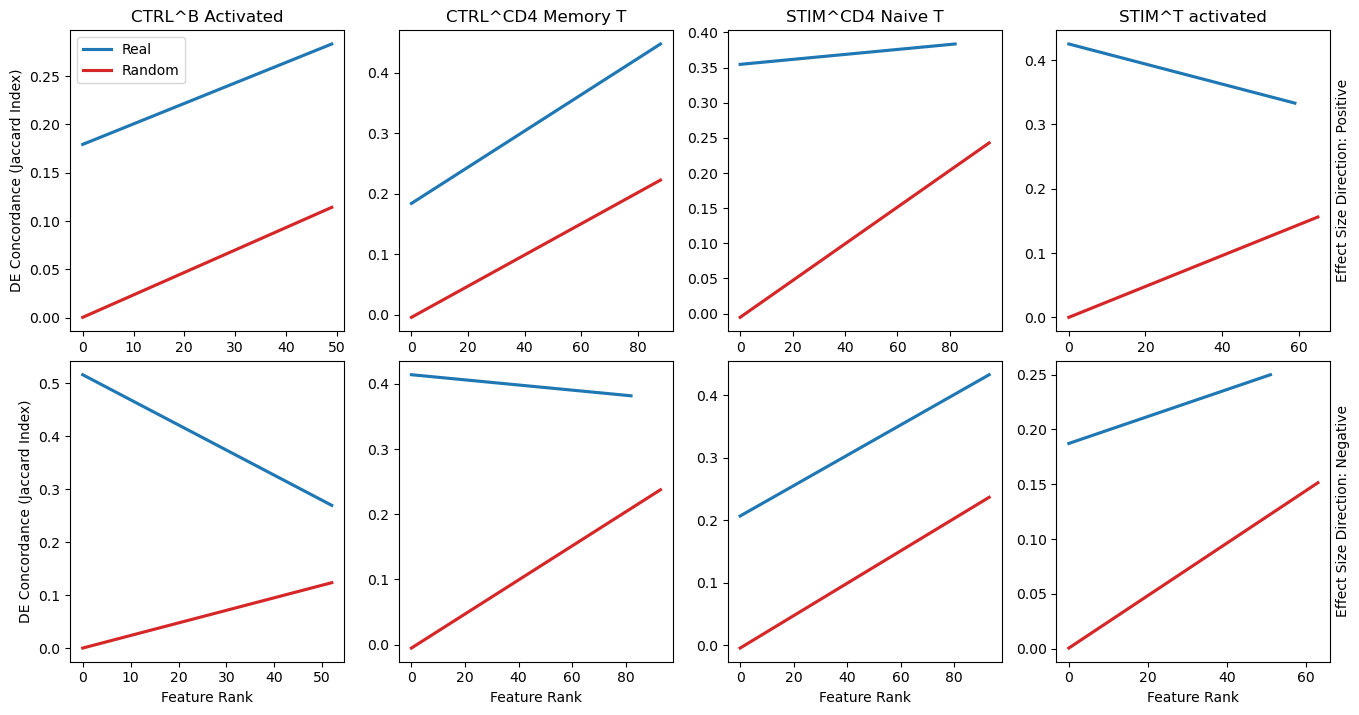

In [60]:
n_cols_max = 5
palette = [sns.color_palette()[0], sns.color_palette()[3]]
conds = concordance_df.test_cond.unique().tolist()

n_blocks = math.ceil(len(conds) / n_cols_max)
fig = plt.figure(figsize=(4.1*n_cols_max, 4.1*(n_blocks*2)))

# Big gap between condition blocks:
outer = fig.add_gridspec(n_blocks, 1, hspace=0.15)  # ← enlarge/reduce inter-block spacing here

for b in range(n_blocks):
    batch = conds[b*n_cols_max:(b+1)*n_cols_max]
    # Tight gap within the 2 rows of the same condition:
    inner = outer[b].subgridspec(2, n_cols_max, hspace=0.1)  
    ax = inner.subplots()  # shape (2, n_cols_max)

    for j, test_cond in enumerate(batch):
        for i, direction in enumerate(['positive', 'negative']):
            viz_df_ = concordance_df[concordance_df.test_cond == test_cond].drop(columns='test_cond')
            viz_df = viz_df_[viz_df_.direction == direction].drop(columns='direction')
            viz_df = pd.melt(viz_df, id_vars=['rank', 'type'], value_name='concordance')

            for k, calc_type in enumerate(['real', 'random']):
                sns.regplot(
                    viz_df[viz_df['type'] == calc_type],
                    x='rank', y='concordance',
                    ci=None, scatter=False, lowess = True, seed = seed,
                    color=palette[k],
                    ax=ax[i, j],
                    label=calc_type.capitalize()
                )

            ax[i, j].set_ylabel(None)
            ax[i, j].set_xlabel(None)

            if j == 0:
                ax[i, j].set_ylabel('DE Concordance (Jaccard Index)')
            if i == 1:
                ax[i, j].set_xlabel('Feature Rank')
            if b == 0 and i == 0 and j == 0:
                ax[i, j].legend()
            if i == 0:
                ax[i, j].set_title(test_cond)
            if j == (len(batch) - 1):
                ax[i, j].set_ylabel(f'Effect Size Direction: {direction.capitalize()}')
                ax[i, j].yaxis.set_label_position("right")

    # remove unused axes in the last block if batch shorter than n_cols_max
    for j in range(len(batch), n_cols_max):
        for i in [0, 1]:
            fig.delaxes(ax[i, j])
fig.tight_layout()
;


## 8.2 Rank-based Metric

<span style="color:red">Need to check how this works when there is binary perturbation</span>


In [65]:
from scLEMBAS.metrics.distances import rank_score

In [67]:
rank_score_average, rank_scores = rank_score(tf_adata_actual = tf_adata.copy(), 
                                                   tf_adata_predicted = tf_adata_predicted, 
                                                   pert_col = 'stim', 
                                                   distance_metric = 'manhattan', 
                                                  )

print('The average rank score is {:.3f}'.format(rank_score_average))

The average rank score is 1.000


In [ ]:
fig, ax = plt.subplots(figsize=(10,5))

viz_df = pd.DataFrame(pd.Series(rank_scores), columns = ['rank_score']).reset_index(drop = False, names = 'perturbation')
viz_df.sort_values(by = 'rank_score', ascending = False, inplace = True)

sns.scatterplot(
    data=viz_df,
    x="perturbation",
    y="rank_score",
    ax=ax,
    zorder=3
)
ymin, ymax = ax.get_ylim()

ax.vlines(
    x=viz_df["perturbation"],
    ymin=0,
    ymax=viz_df["rank_score"],
    colors="gray",
    linestyles="dashed",
    zorder=1
)

xmin, xmax = ax.get_xlim()

ax.hlines(
    y=rank_score_average,
    xmin=xmin,
    xmax=xmax,
    colors="black",
    label = 'Average Rank Score',
    linewidth = 0.5, 
    zorder = 2
)

ax.hlines(
    y=0.5,
    xmin=xmin,
    xmax=xmax,
    colors="red",
    label = 'Expected Random Score',
    linewidth = 0.5, 
    zorder = 2
)

ax.set_xlim(xmin, xmax)
if ymin > 0.5:
    ymin = 0.45
    ymax *= 1.05
ax.set_ylim(ymin, ymax)

ax.set_ylabel("Rank Score")
ax.set_xlabel("Perturbation")

ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

;


To understand the extendt this is driven simply by cell line variance, let's see how many cell lines each perturbation maps to. If the ones that only have one cell line associated are the ones with the highest rank scores, this may simply be the model capturing cell line and not perturbation variance:

In [ ]:
from collections import defaultdict
counts = defaultdict(set)
for entry in tf_adata_predicted.obs.condition.unique():
    celltype, pert = entry.split("^")
    counts[pert].add(celltype)

counts = {pert: len(celltypes) for pert, celltypes in counts.items()}
counts = dict(sorted(counts.items(), key=lambda x: x[1], reverse=True))
counts
